This notebook is an analysis of the Titanic competition on Kaggle.

Competition web address: https://www.kaggle.com/competitions/titanic

In this notebook I"d like to investigate GLMs and tree models. In particular, I plan to use logistic regression and XGBoost. However, as I made progress in my analysis, I decided to also introduce 

---

Importing libraries for data analysis:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import os
#os.chdir(os.path.dirname(os.path.abspath(__file__)))

Reading data:

In [3]:
labelled_file_path = "./data/train.csv"
labelled_data = pd.read_csv(labelled_file_path)
unlabelled_file_path = "./data/test.csv"
unlabelled_data = pd.read_csv(unlabelled_file_path)

total_data = pd.concat([labelled_data, unlabelled_data])

---

### Basic data exploration:

In [4]:
# Print shape and fields
print("Labelled data structure:")
print(labelled_data.shape[0], "entries (rows) and", labelled_data.shape[1], "fields (columns).")
print("The fields are:", list(labelled_data.columns))

print()

print("Unlabelled data structure:")
print(unlabelled_data.shape[0], "entries (rows) and", unlabelled_data.shape[1], "fields (columns).")
print("The fields are:", list(unlabelled_data.columns))

Labelled data structure:
891 entries (rows) and 12 fields (columns).
The fields are: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Unlabelled data structure:
418 entries (rows) and 11 fields (columns).
The fields are: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# See example entries
print("Labelled data header:")
print(labelled_data.head())

print()

print("Unlabelled data header:")
print(labelled_data.head())

Labelled data header:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.05

In [6]:
# Calculate statistics for numerical data
print("Labelled data statistics:")
print(labelled_data.describe())

print()

print("Unlabelled data statistics:")
print(unlabelled_data.describe())

Labelled data statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Unlabelled data statistics:
       PassengerId      Pc

Check missing data:

In [7]:
print("Labelled data:")
labelled_data_isnull = labelled_data.isnull()
print("Number of entries with at least one missing values:", labelled_data_isnull.any(axis=1).sum())
print("Number of missing values by fields:")
print(labelled_data_isnull.sum())

print()

print("Unlabelled data:")
unlabelled_data_isnull = unlabelled_data.isnull()
print("Number of entries with at least one missing values:", unlabelled_data_isnull.any(axis=1).sum())
print("Number of missing values by fields:")
print(unlabelled_data_isnull.sum())

Labelled data:
Number of entries with at least one missing values: 708
Number of missing values by fields:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Unlabelled data:
Number of entries with at least one missing values: 331
Number of missing values by fields:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### Interpretation of each field and data cleaning:

We will clean and encode the data as we go through each field. So let us make containers for the cleaned labelled data and unlabelled data, and add data to them as we go. The PassengerId field is added for now to allow locating exact entries during the data cleaning process, and will be removed after finishing data cleaning.

In [8]:
clean_labelled_data = pd.DataFrame({"PassengerId" : labelled_data["PassengerId"], "Survived": labelled_data["Survived"]})
clean_unlabelled_data = pd.DataFrame({"PassengerId" : unlabelled_data["PassengerId"]})

print("Clean labelled data header:")
print(clean_labelled_data.head())

print("Clean unlabelled data header:")
print(clean_unlabelled_data.head())

Clean labelled data header:
   PassengerId  Survived
0            1         0
1            2         1
2            3         1
3            4         1
4            5         0
Clean unlabelled data header:
   PassengerId
0          892
1          893
2          894
3          895
4          896


__Survived:__

1 - survived, 0 - not survived. This is the field we wish to predict.

__Pclass:__

Pclass stands for the class of tickets. 1 - 1st; 2 - 2nd, 3 - 3rd. This would be a useful indicator of the passengers social class. The higher-class ticket-holders had quicker access to the deckboard, which increased their survival rates. (See https://www.encyclopedia-titanica.org/titanic-deckplans/ for Titanic's layout.)

Text(0.5, 1.0, 'Survival rates by ticket classes')

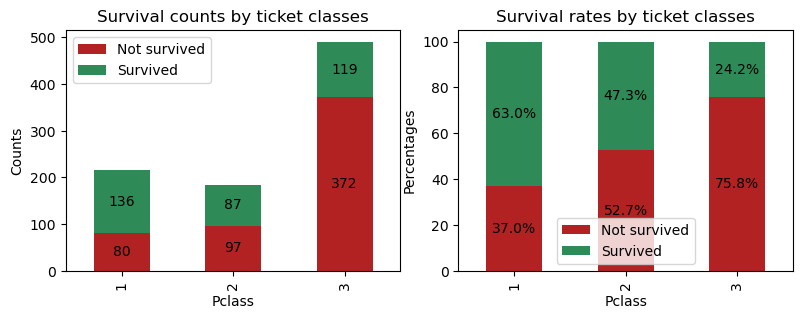

In [9]:
temp = labelled_data.copy(deep = False)

counts = temp["Pclass"].value_counts()

survived_counts = temp.groupby("Pclass", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by ticket classes")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by ticket classes")


Passengers with higher class tickets had higher survival rates.

Since the values are quantitative and ordered (lower values correlate to higher social classes), we will add it to the cleaned data without changes.

In [10]:
clean_labelled_data["Pclass"] = labelled_data["Pclass"]
clean_unlabelled_data["Pclass"] = unlabelled_data["Pclass"]

print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass
0            1         0       3
1            2         1       1
2            3         1       3
3            4         1       1
4            5         0       3


__Name:__

We can extract the titles of passengers from this field. This field will be particularly helpful in imputing the missing ages of passengers. For example, a title of "Master." would indicate a boy, a title of "Mrs." would indicate a married woman.

Let us firsly have a look at the existing titles from both training data and testing data by a regex match:

In [11]:
names = pd.concat([labelled_data["Name"], unlabelled_data["Name"]], axis = 0)

titles = names.str.extract(r",\s([^\.]*)") # Matches everything that comes after a white space and before a dot character
titles.value_counts()

0           
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Ms                2
Mlle              2
Major             2
Capt              1
Don               1
Dona              1
Jonkheer          1
Lady              1
Mme               1
Sir               1
the Countess      1
Name: count, dtype: int64

Let us look at the less common titles:
- Mlle is Miss in French.
- Mme is Mrs in French.
- Ms is just another way to write Miss.
- Rev is a Christian title . All passengers with this title have a 2nd-class ticket.
- Major, Col, Capt are high military ranks. All passengers with this title have a 1st-class ticket.
- Lady, Sir, the Countess, Don, Dona, Jonkheer are all nobility titles. All passengers with this title have a 1st-class ticket.

We will now clean the data as follows:
- Rewrite Mlle, Mme, Ms to Miss, Mrs and Miss.
- Group Major, Col, Capt into one military category.
- Group Lady, Sir etc. into one nobility category.
- One-hot encode all titles with categories: Mr, Miss, Mrs, Master, Dr, Rev, Military, Nobility.

(To avoid singular matrices, we miss out the Nobility category, which is represented by a $0$ across all other one-hot encoding indicators.)

In [12]:
# Create a Title field and extract all titles from Name field
temp_titles = labelled_data["Name"].str.extract(r",\s([^\.]*)", expand = False)

# Rewrite rare titles into respective categories
temp_titles = temp_titles.replace("Mlle", "Miss")
temp_titles = temp_titles.replace("Mme", "Mrs")
temp_titles = temp_titles.replace("Ms", "Miss")
temp_titles = temp_titles.replace("(Major|Col|Capt)", "Military", regex=True)
temp_titles = temp_titles.replace("(Lady|Sir|the Countess|Don|Dona|Jonkheer)", "Nobility", regex=True)

# Save the title field
clean_labelled_data["Title"] = temp_titles
#------------------------------------------------
# Now do the same for testing data

# Create a Title field and extract all titles from Name field
temp_titles = unlabelled_data["Name"].str.extract(r",\s([^\.]*)", expand = False)

# Rewrite rare titles into respective categories
temp_titles = temp_titles.replace("Mlle", "Miss")
temp_titles = temp_titles.replace("Mme", "Mrs")
temp_titles = temp_titles.replace("Ms", "Miss")
temp_titles = temp_titles.replace("(Major|Col|Capt)", "Military", regex=True)
temp_titles = temp_titles.replace("(Lady|Sir|the Countess|Dona|Don|Jonkheer)", "Nobility", regex=True)

# Save the title field
clean_unlabelled_data["Title"] = temp_titles
#------------------------------------------------
print("Title counts for labelled data:")
print(clean_labelled_data["Title"].value_counts())

print()

print("Title counts for unlabelled data:")
print(clean_unlabelled_data["Title"].value_counts())

print()

print("Clean labelled data header:")
print(clean_labelled_data.head())

Title counts for labelled data:
Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Nobility      5
Military      5
Name: count, dtype: int64

Title counts for unlabelled data:
Title
Mr          240
Miss         79
Mrs          72
Master       21
Military      2
Rev           2
Dr            1
Nobility      1
Name: count, dtype: int64

Clean labelled data header:
   PassengerId  Survived  Pclass Title
0            1         0       3    Mr
1            2         1       1   Mrs
2            3         1       3  Miss
3            4         1       1   Mrs
4            5         0       3    Mr


In [13]:
# One-hot-encode the Title field, dropping Nobility to avoid singular matrices during later training process
one_hot_titles = pd.get_dummies(clean_labelled_data["Title"], dtype = int)
one_hot_titles = one_hot_titles.drop("Nobility", axis = 1)

# Concatenate the one-hot-encoded fields to data
clean_labelled_data = pd.concat([clean_labelled_data, one_hot_titles], axis = 1)

# Drop the Title field as it is no longer needed
clean_labelled_data = clean_labelled_data.drop("Title", axis = 1)
#------------------------------------------------
# Now do the same for testing data

# One-hot-encode the Title field, dropping Nobility to avoid singular matrices during later training process
one_hot_titles = pd.get_dummies(clean_unlabelled_data["Title"], dtype = int)
one_hot_titles = one_hot_titles.drop("Nobility", axis = 1)

# Concatenate the one-hot-encoded fields to data
clean_unlabelled_data = pd.concat([clean_unlabelled_data, one_hot_titles], axis = 1)

# Drop the Title field as it is no longer needed
clean_unlabelled_data = clean_unlabelled_data.drop("Title", axis = 1)
#------------------------------------------------
print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev
0            1         0       3   0       0         0     0   1    0    0
1            2         1       1   0       0         0     0   0    1    0
2            3         1       3   0       0         0     1   0    0    0
3            4         1       1   0       0         0     0   0    1    0
4            5         0       3   0       0         0     0   1    0    0


__Sex:__

The only entries in this field are male and female. There was a "women and chilren first" protocol on Titanic which could cause a correlation between sex and survival rate. Let us explore this by visualisation:

Text(0.5, 1.0, 'Survival rates by Sex')

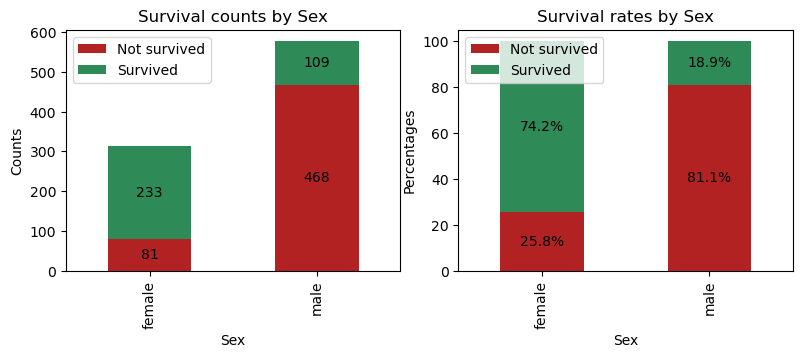

In [14]:
temp = labelled_data.copy(deep = False)

counts = temp["Sex"].value_counts()

survived_counts = temp.groupby("Sex", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Sex")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Sex")


By a drastically higher survival rate of women, we could presume that the "women and children first" protocol was mostly adhered to. In which means we may also expect a higher survival rate of children.

We will encode this field to numerical data by 0 - male and 1 - female. To make the dataset more readable, we will change the field name to "IsFemale".

In [15]:
# Map to numerical data and renaming the field
clean_labelled_data["IsFemale"] = labelled_data["Sex"].map({"male":0, "female":1})

# Do the same for testing data
clean_unlabelled_data["IsFemale"] = unlabelled_data["Sex"].map({"male":0, "female":1})
#------------------------------------------------
print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale  
0         0  
1         1  
2         1  
3         1  
4         0  


__Age:__

There are missing values for this field. Since the fraction of missing values for age is small, we might have enough information to fill in the missing data. (We do this after cleaning up all other fields.)

There are a lot of confounding factors here - the poor health of old people, the lack of experience of children, and the "women and children first" protocol. To understand how age affects the survival rate, let us have a visualisation (excluding the entries with missing ages):

Text(0.5, 1.0, 'Survival rates by Age groups')

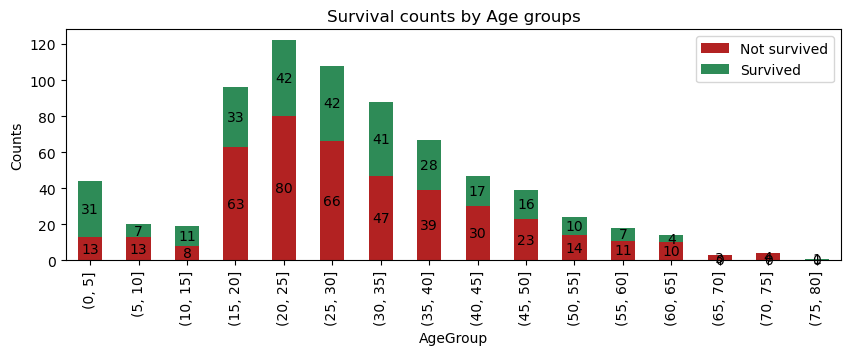

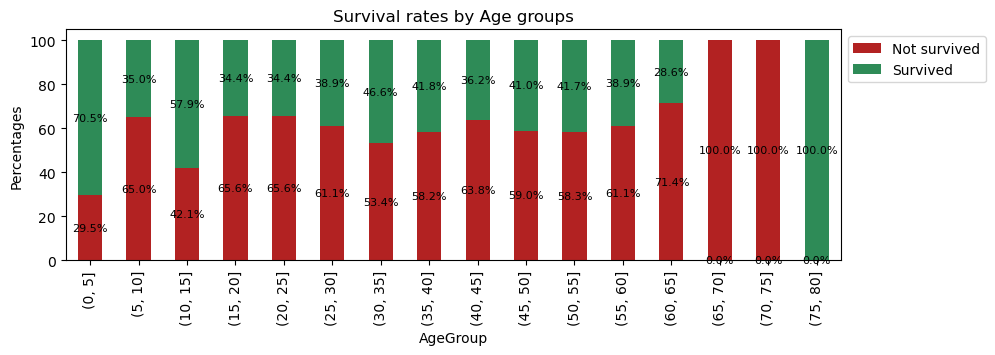

In [16]:
temp = labelled_data.copy(deep = False)
temp = temp.dropna(subset = "Age") # Some age entries are missing, so we omit them.

# Classify entries into age groups
age_bins = np.arange(0,81,5)
age_groups = pd.cut(temp["Age"], bins = age_bins) # Returns an array classifying passengers into age group

temp["AgeGroup"] = age_groups
survival_counts = temp.groupby("AgeGroup", observed = False)["Survived"].value_counts()

fig_count, ax_count = plt.subplots()
fig_count.set_size_inches(10,3)
survival_counts.unstack().plot(kind="bar", stacked = True, ax = ax_count, color = ["firebrick", "seagreen"])
ax_count.legend(["Not survived", "Survived"], bbox_to_anchor=(1,1))
ax_count.bar_label(ax_count.containers[0], label_type = "center")
ax_count.bar_label(ax_count.containers[1], label_type = "center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Age groups")

age_group_counts = temp["AgeGroup"].value_counts().sort_index()
survival_percentages = 100 * survival_counts / age_group_counts

fig_percentage, ax_percentage = plt.subplots()
fig_percentage.set_size_inches(10,3)
survival_percentages.unstack().plot(kind="bar", stacked = True, ax = ax_percentage, color = ["firebrick", "seagreen"])
ax_percentage.legend(["Not survived", "Survived"], bbox_to_anchor=(1,1))
ax_percentage.bar_label(ax_percentage.containers[0], fmt = "%.1f%%", label_type = "center", fontsize=8)
ax_percentage.bar_label(ax_percentage.containers[1], fmt = "%.1f%%", label_type = "center", fontsize=8)
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Age groups")

It seems like children generally have a higher survival rate than adults, except that there is a mysterious dip in survival rate for children aged between 5 and 10. Since the population of children aged between 5 and 10 is small (only 20 in the training data set), it is possible that this is just an anomaly.

The survival chances for old people (aged 65 and over) are not large enough to be representative, so we don"t draw conclusions from it.

We add this field to our data, since there is a weak decreasing trend of survivability as age increases.

In [17]:
clean_labelled_data["Age"] = labelled_data["Age"]
clean_unlabelled_data["Age"] = unlabelled_data["Age"]

print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale   Age  
0         0  22.0  
1         1  38.0  
2         1  26.0  
3         1  35.0  
4         0  35.0  


__SibSp:__

SibSp stands for the number of siblings and spouses abroad.

It would be helpful if we could know their individual numbers. One possible way to do this is to investigate the name column and try to match couples by surnames, but this approach can be inaccurate due to duplicate surnames.

Text(0.5, 1.0, 'Survival rates by number of siblings and spouses abroad')

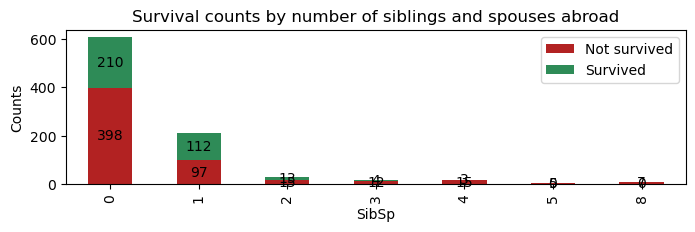

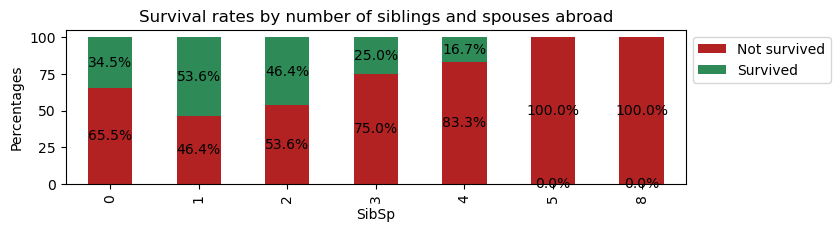

In [18]:
temp = labelled_data.copy(deep = False)

counts = temp["SibSp"].value_counts()

survived_counts = temp.groupby("SibSp", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig_count, ax_count = plt.subplots()
fig_count.set_size_inches(8,2)

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"], bbox_to_anchor=(1,1))
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by number of siblings and spouses abroad")

fig_percentage, ax_percentage = plt.subplots()
fig_percentage.set_size_inches(8,2)

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"], bbox_to_anchor=(1,1))
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by number of siblings and spouses abroad")

It is expected that passengers with no siblings nor spouses abroad have a low survival rate. What is interesting is that passengers with many siblings and spouses have an even lower survival rate!

__Parch:__

Parch stands for the number of parents and children abroad.

This is an interesting metric because intuitively the same value can go both ways. A child with a parent onboard would be expected to have a higher chance of survival, whilst a parent with a child onboard may give up their space on lifeboat for their children.

Text(0.5, 1.0, 'Survival rates by ticket Parch')

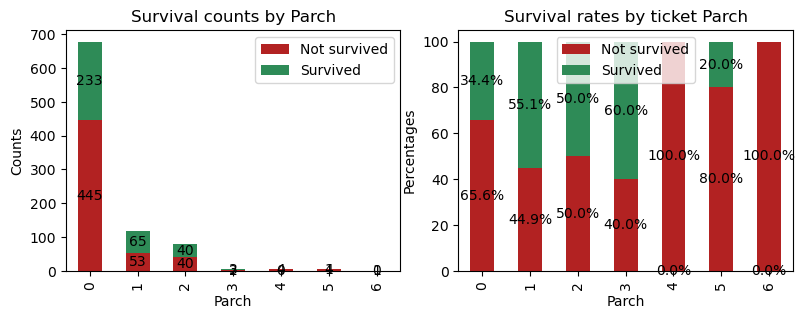

In [19]:
temp = labelled_data.copy(deep = False)

counts = temp["Parch"].value_counts()

survived_counts = temp.groupby("Parch", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Parch")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by ticket Parch")


Doesn't look very conclusive? More information can be found by grouping passengers into four categories:

Text(0.5, 1.0, 'Survival rates by Parch, for age <= 16, male')

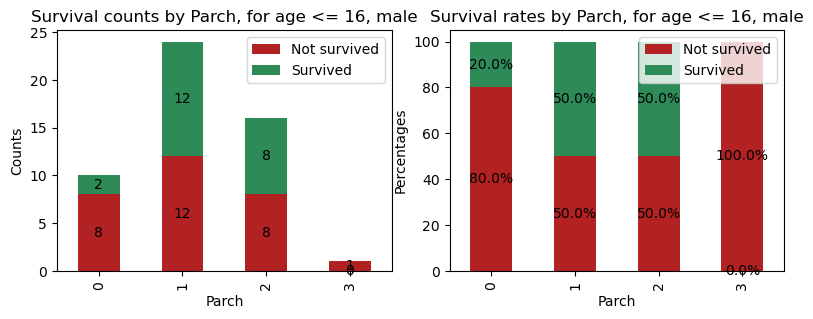

In [20]:
temp = labelled_data.copy(deep = False)
temp = temp.dropna(subset = "Age") # Some age entries are missing, so we omit them.

# Group 1: Passegers with age <= 16, male
temp_group = temp[(temp["Age"] <= 16) & (temp["Sex"] == "male")]

parch_counts = temp_group["Parch"].value_counts()

parch_survived_counts = temp_group.groupby("Parch", observed = False)["Survived"].value_counts().sort_index()
parch_percentages = 100 * parch_survived_counts / parch_counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
plt.tight_layout()

parch_survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Parch, for age <= 16, male")

parch_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Parch, for age <= 16, male")


Text(0.5, 1.0, 'Survival rates by Parch, for age <= 16, female')

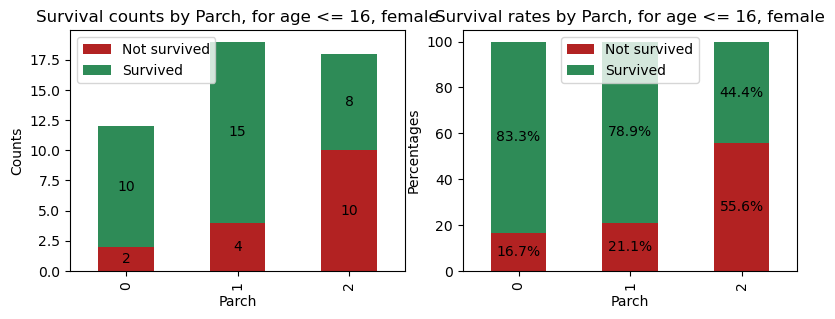

In [21]:
temp = labelled_data.copy(deep = False)
temp = temp.dropna(subset = "Age") # Some age entries are missing, so we omit them.

# Group 2: Passegers with age <= 16, female
temp_group = temp[(temp["Age"] <= 16) & (temp["Sex"] == "female")]

parch_counts = temp_group["Parch"].value_counts()

parch_survived_counts = temp_group.groupby("Parch", observed = False)["Survived"].value_counts().sort_index()
parch_percentages = 100 * parch_survived_counts / parch_counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
plt.tight_layout()

parch_survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Parch, for age <= 16, female")

parch_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Parch, for age <= 16, female")


Text(0.5, 1.0, 'Survival rates by Parch, for age > 16, male')

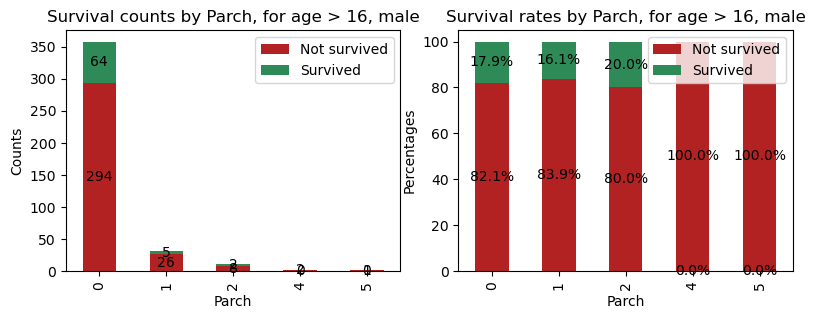

In [22]:
temp = labelled_data.copy(deep = False)
temp = temp.dropna(subset = "Age") # Some age entries are missing, so we omit them.

# Group 3: Passegers with age > 16, male
temp_group = temp[(temp["Age"] > 16) & (temp["Sex"] == "male")]

parch_counts = temp_group["Parch"].value_counts()

parch_survived_counts = temp_group.groupby("Parch", observed = False)["Survived"].value_counts().sort_index()
parch_percentages = 100 * parch_survived_counts / parch_counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
plt.tight_layout()

parch_survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Parch, for age > 16, male")

parch_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Parch, for age > 16, male")


Text(0.5, 1.0, 'Survival rates by Parch, for age > 16, female')

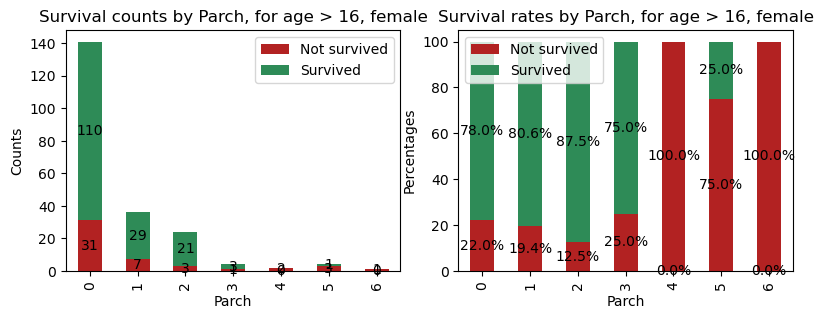

In [23]:
temp = labelled_data.copy(deep = False)
temp = temp.dropna(subset = "Age") # Some age entries are missing, so we omit them.

# Group 4: Passegers with age > 16, female
temp_group = temp[(temp["Age"] > 16) & (temp["Sex"] == "female")]

parch_counts = temp_group["Parch"].value_counts()

parch_survived_counts = temp_group.groupby("Parch", observed = False)["Survived"].value_counts().sort_index()
parch_percentages = 100 * parch_survived_counts / parch_counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8,3))
plt.tight_layout()

parch_survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by Parch, for age > 16, female")

parch_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by Parch, for age > 16, female")


Firstly, we note that the statistics of high Parch values are not representatibe due to the small population sizes.

For passengers aged over 16, their survival rate doesn't seem to be much affected by Parch, but predominantly affected by their genders - these survival rates are very comparable to the overall survival rates per respective gender. (Note the Simpson's paradox here!)

For children this is a little different. Boys with a non-zero Parch had better survival rates. However, it is surprising that girls with a value of 2 in Parch had a lower than usual survival rate! Since the number of children is small, they could all be outliers - it is hard to tell from data alone.

__SibSp and Parch__:

Since neither SibSp and Parch show clear correlations with survival rates, yet intuitively there should be a positive correlation, we may suspect that there are confounding factors in the play.

Let us try to create a field called "FamilySize" which is the sum of Parch and Sibsp, and explore the statistics.

Text(0.5, 1.0, 'Survival rates by family sizes')

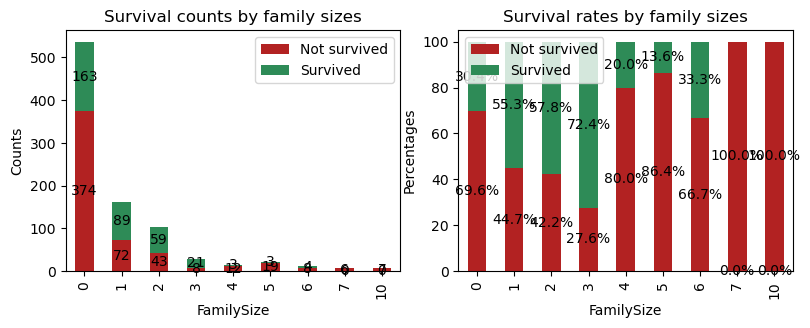

In [24]:
family_size = labelled_data["Parch"] + labelled_data["SibSp"]

temp = pd.DataFrame({"FamilySize" : family_size, "Survived" : labelled_data["Survived"]})

counts = temp["FamilySize"].value_counts()

survived_counts = temp.groupby("FamilySize", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by family sizes")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by family sizes")


And indeed it seems like the size of family is more relevant! Let us add this to the cleaned dataset, and remove the Parch and SibSp field which may confuse the models.

There are outliers for large family sizes - we apply a log transform to minimise the effect of these skewed values on models like GLM.

In [25]:
clean_labelled_data["LogFamilySize"] = np.log(1 + labelled_data["Parch"] + labelled_data["SibSp"])
clean_unlabelled_data["LogFamilySize"] = np.log(1 + unlabelled_data["Parch"] + unlabelled_data["SibSp"])

print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale   Age  LogFamilySize  
0         0  22.0       0.693147  
1         1  38.0       0.693147  
2         1  26.0       0.000000  
3         1  35.0       0.693147  
4         0  35.0       0.000000  


__Ticket and Fare:__

This Ticket field contains the ticket numbers of the passengers. Unfortunately, it is difficult to find reliable information regarding the meanings of these numbers.

The Fare field contains the price of the ticket.

An interesting fact is that there are tickets for groups of passengers, which makes those tickets much more expensive and causes a lot of noise for the Fare field. Luckily we have information to the ticket numbers, so we can identify the number of passengers for each ticket, and calculate the average fare for tickets.

Since the Kaggle competition splits the data into a training and a testing set, we need to sum up the the occurrences of ticket numbers in both files to know the actual number of passengers on the ticket.

A problem is that there is one missing fare value in the unlabelled data, which we will handle after calculating the average fare.

In [26]:
# Count the number of occurrences with indices as ticket numbers
ticket_size_per_ticket = total_data["Ticket"].value_counts()

# Calculate the average fare for tickets
clean_labelled_data["AvgFare"] = labelled_data["Fare"] / labelled_data["Ticket"].map(ticket_size_per_ticket)
clean_unlabelled_data["AvgFare"] = unlabelled_data["Fare"] / unlabelled_data["Ticket"].map(ticket_size_per_ticket)

print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale   Age  LogFamilySize   AvgFare  
0         0  22.0       0.693147   7.25000  
1         1  38.0       0.693147  35.64165  
2         1  26.0       0.000000   7.92500  
3         1  35.0       0.693147  26.55000  
4         0  35.0       0.000000   8.05000  


Since we calculated the average fares, let us have a look at the survival rates against average fares!

Text(0.5, 1.0, 'Survival rates by average fare groups')

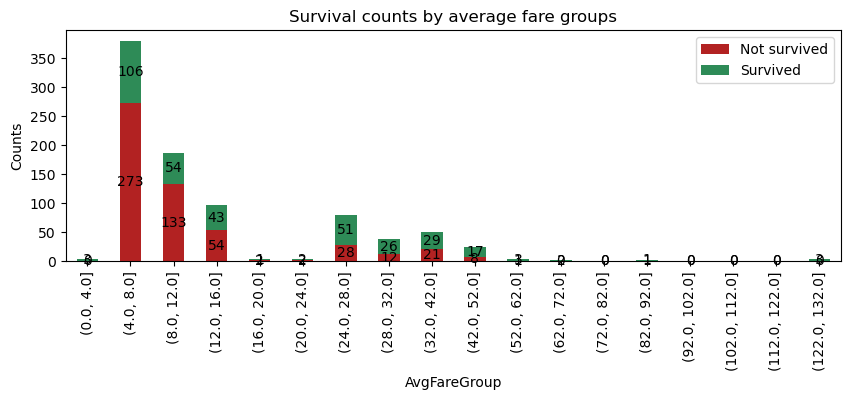

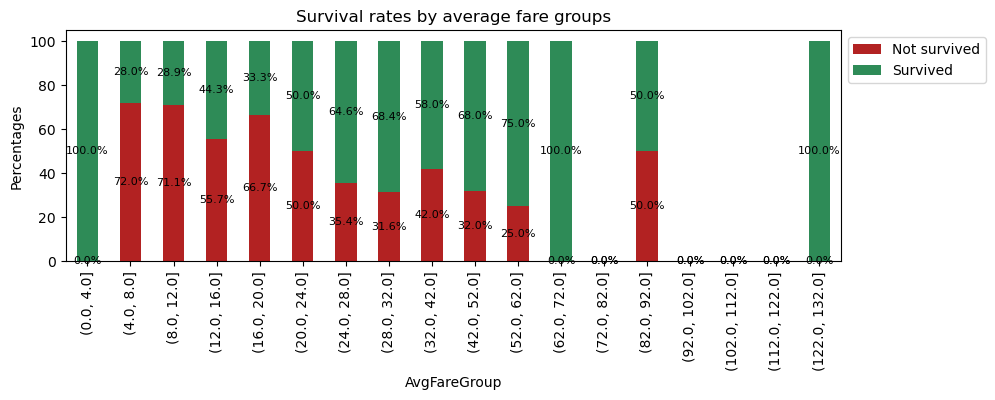

In [27]:
temp = pd.DataFrame({"Survived" : labelled_data["Survived"], "AvgFare" : clean_labelled_data["AvgFare"]})

# Classify entries into fare groups
fare_bins = np.concatenate([np.arange(0,28.05,4), np.arange(32, 132.05, 10)])
fare_groups = pd.cut(temp["AvgFare"], bins = fare_bins) # Returns an array classifying passengers into fare groups

temp["AvgFareGroup"] = fare_groups
survival_counts = temp.groupby("AvgFareGroup", observed = False)["Survived"].value_counts()

fig_count, ax_count = plt.subplots()
fig_count.set_size_inches(10,3)
survival_counts.unstack().plot(kind="bar", stacked = True, ax = ax_count, color = ["firebrick", "seagreen"])
ax_count.legend(["Not survived", "Survived"], bbox_to_anchor=(1,1))
ax_count.bar_label(ax_count.containers[0], label_type = "center")
ax_count.bar_label(ax_count.containers[1], label_type = "center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by average fare groups")

fare_group_counts = temp["AvgFareGroup"].value_counts().sort_index()
survival_percentages = 100 * survival_counts / fare_group_counts

fig_percentage, ax_percentage = plt.subplots()
fig_percentage.set_size_inches(10,3)
survival_percentages.unstack().plot(kind="bar", stacked = True, ax = ax_percentage, color = ["firebrick", "seagreen"])
ax_percentage.legend(["Not survived", "Survived"], bbox_to_anchor=(1,1))
ax_percentage.bar_label(ax_percentage.containers[0], fmt = "%.1f%%", label_type = "center", fontsize=8)
ax_percentage.bar_label(ax_percentage.containers[1], fmt = "%.1f%%", label_type = "center", fontsize=8)
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by average fare groups")

Higher fares are correlated with higher survival rates - except the outliers with small sample sizes. To minimise the effect of ourliers, let us use a log transform on the average fare.

In [28]:
# Convert average fare to the natural log of average fare
clean_labelled_data["LogAvgFare"] = np.log(1 + clean_labelled_data["AvgFare"])
clean_labelled_data = clean_labelled_data.drop("AvgFare", axis = 1)

# Do the same on unlabelled data
clean_unlabelled_data["LogAvgFare"] = np.log(1 + clean_unlabelled_data["AvgFare"])
clean_unlabelled_data = clean_unlabelled_data.drop("AvgFare", axis = 1)

print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale   Age  LogFamilySize  LogAvgFare  
0         0  22.0       0.693147    2.110213  
1         1  38.0       0.693147    3.601186  
2         1  26.0       0.000000    2.188856  
3         1  35.0       0.693147    3.316003  
4         0  35.0       0.000000    2.202765  


Now we address the missing fare in unlabelled data. Firstly we identify the entry:

In [29]:
print(unlabelled_data[unlabelled_data["Fare"].isna()])

     PassengerId  Pclass                Name   Sex   Age  SibSp  Parch Ticket  \
152         1044       3  Storey, Mr. Thomas  male  60.5      0      0   3701   

     Fare Cabin Embarked  
152   NaN   NaN        S  


Let us check how many passengers held the same ticket number:

In [30]:
print(total_data[total_data["Ticket"] == "3701"])

     PassengerId  Survived  Pclass                Name   Sex   Age  SibSp  \
152         1044       NaN       3  Storey, Mr. Thomas  male  60.5      0   

     Parch Ticket  Fare Cabin Embarked  
152      0   3701   NaN   NaN        S  


Just himself! We know that he was around 60 years old and held a 3rd-class ticket. Let us check the log average fare of 3-rd class ticket holders:

In [31]:
temp = pd.concat([clean_labelled_data, clean_unlabelled_data])
print(temp[temp["Pclass"] == 3]["LogAvgFare"].describe())

count    708.000000
mean       2.099456
std        0.229387
min        0.000000
25%        2.086917
50%        2.169054
75%        2.188856
max        3.042935
Name: LogAvgFare, dtype: float64


We see that the standard deviation is very small. Since there is only one missing data, let us simply fill it in with the mean, which should be $2.169054$ from the previous block's output.

In [32]:
clean_unlabelled_data.loc[clean_unlabelled_data["PassengerId"] == 1044, "LogAvgFare"] = 2.169054

print("Updated entry:")
print(clean_unlabelled_data.loc[clean_unlabelled_data["PassengerId"] == 1044])

Updated entry:
     PassengerId  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  IsFemale  \
152         1044       3   0       0         0     0   1    0    0         0   

      Age  LogFamilySize  LogAvgFare  
152  60.5            0.0    2.169054  


__Cabin:__

This is the cabin number of the passenger. The letter represents the deck, whilst the numeric part represents the room number. Some decks, like the A deck, is much closer to the boat deck containing the life boats.

The room number encodes locational information, but a model would not understand this directly. One possible appraoch is to estimate the time needed to move to the boat deck using layout maps of Titanic. We will not do this due to the unjustifiable amount of effort needed.

The cabin number information mostly comes from the Cave List (https://www.encyclopedia-titanica.org/cave-list.html) which contains the cabin numbers for most of the first class passengers. So, the existence of data is correlated to the status of a first-class passenger. Nevertheless, we have direct access to Pclass, so this information is duplicated.

Since a large fraction of entries are missing the cabin number, we may simply omit this field from consideration, as attempts to fill in the missing data will likely be inaccurate.

Let us have a look at the deck letters of the existing cabin numbers, by removing all digits and whitespaces from the Cabin values:

In [33]:
cabin_numbers = pd.concat([labelled_data["Cabin"], unlabelled_data["Cabin"]])
deck_letters = cabin_numbers.str.replace(r"[\s\d]", "", regex=True)
deck_letters.value_counts()

Cabin
C       80
B       48
D       44
E       40
A       22
F       14
BB       8
CC       8
CCC      6
BBBB     5
G        5
FG       4
BBB      4
FE       3
DD       2
T        1
EE       1
Name: count, dtype: int64

There are passengers who purchased tickets for multiple cabins.

__Embarked:__

This is the location where the passenger embarks Titanic. C = Cherbourg (in France), Q = Queenstown (now known as Cobh, in Ireland), S = Southampton (in England).

Text(0.5, 1.0, 'Survival rates by ticket classes')

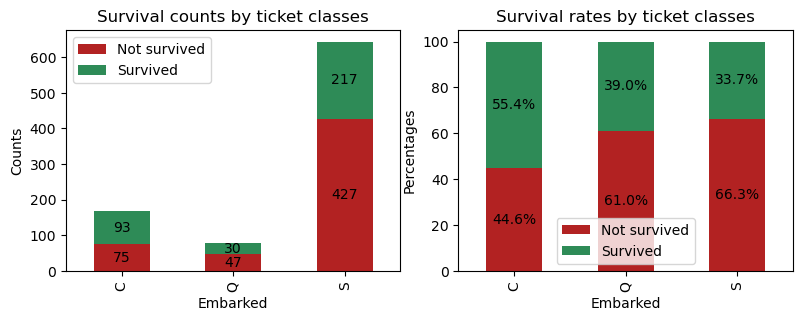

In [34]:
temp = labelled_data.copy(deep = False)

embarked_counts = temp["Embarked"].value_counts()

embarked_survived_counts = temp.groupby("Embarked", observed = False)["Survived"].value_counts().sort_index()

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

embarked_survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Survival counts by ticket classes")

embarked_percentages = 100 * embarked_survived_counts / embarked_counts

embarked_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Survival rates by ticket classes")

We will include this field under the hypothesis that cultural and economic differences do affect the survival rates.

We use one-hot encoding for it. But first, let us fill in the missing values in labelled data:

In [35]:
print(labelled_data[labelled_data["Embarked"].isna()])

     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  
61   female  38.0      0      0  113572  80.0   B28      NaN  
829  female  62.0      0      0  113572  80.0   B28      NaN  


By the information found on the Encyclopedia Titanica, we know that Miss. Amelie was a maid of Mrs. George Nelson, and they both boarded the ship in Southampton.

(References: https://www.encyclopedia-titanica.org/titanic-survivor/amelia-icard.html and https://www.encyclopedia-titanica.org/titanic-survivor/martha-stone.html)

Filling in the data:

In [36]:
labelled_data.loc[labelled_data["PassengerId"] == 62, "Embarked"] = "S"
labelled_data.loc[labelled_data["PassengerId"] == 830, "Embarked"] = "S"

print("Updated entries:")
print(labelled_data.loc[labelled_data["PassengerId"] == 62])
print(labelled_data.loc[labelled_data["PassengerId"] == 830])

Updated entries:
    PassengerId  Survived  Pclass                 Name     Sex   Age  SibSp  \
61           62         1       1  Icard, Miss. Amelie  female  38.0      0   

    Parch  Ticket  Fare Cabin Embarked  
61      0  113572  80.0   B28        S  
     PassengerId  Survived  Pclass                                       Name  \
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  
829  female  62.0      0      0  113572  80.0   B28        S  


Now we perform one-hot-encoding:

In [37]:
# One-hot-encode the Embarked field, dropping S to avoid singular matrices during later training process
one_hot_embarked = pd.get_dummies(labelled_data["Embarked"], dtype = int)
one_hot_embarked = one_hot_embarked.drop("S", axis = 1)

# Concatenate the one-hot-encoded fields to data
clean_labelled_data = pd.concat([clean_labelled_data, one_hot_embarked], axis = 1)
#------------------------------------------------
# Now do the same for testing data

# One-hot-encode the Title field, dropping Nobility to avoid singular matrices during later training process
one_hot_embarked = pd.get_dummies(unlabelled_data["Embarked"], dtype = int)
one_hot_embarked = one_hot_embarked.drop("S", axis = 1)

# Concatenate the one-hot-encoded fields to data
clean_unlabelled_data = pd.concat([clean_unlabelled_data, one_hot_embarked], axis = 1)
#------------------------------------------------
print("Clean labelled data header:")
print(clean_labelled_data.head())

Clean labelled data header:
   PassengerId  Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  \
0            1         0       3   0       0         0     0   1    0    0   
1            2         1       1   0       0         0     0   0    1    0   
2            3         1       3   0       0         0     1   0    0    0   
3            4         1       1   0       0         0     0   0    1    0   
4            5         0       3   0       0         0     0   1    0    0   

   IsFemale   Age  LogFamilySize  LogAvgFare  C  Q  
0         0  22.0       0.693147    2.110213  0  0  
1         1  38.0       0.693147    3.601186  1  0  
2         1  26.0       0.000000    2.188856  0  0  
3         1  35.0       0.693147    3.316003  0  0  
4         0  35.0       0.000000    2.202765  0  0  


__Concluding data pre-processing:__

We will no longer need to identify individual passengers, so we remove the PassengerId field from our data:

In [38]:
clean_labelled_data = clean_labelled_data.drop("PassengerId", axis = 1)
clean_unlabelled_data = clean_unlabelled_data.drop("PassengerId", axis = 1)

Final visual inspection:

In [39]:
print("Clean labelled data header:")
print(clean_labelled_data.head())

print()

print("Clean unlabelled data header:")
print(clean_unlabelled_data.head())

Clean labelled data header:
   Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  IsFemale   Age  \
0         0       3   0       0         0     0   1    0    0         0  22.0   
1         1       1   0       0         0     0   0    1    0         1  38.0   
2         1       3   0       0         0     1   0    0    0         1  26.0   
3         1       1   0       0         0     0   0    1    0         1  35.0   
4         0       3   0       0         0     0   1    0    0         0  35.0   

   LogFamilySize  LogAvgFare  C  Q  
0       0.693147    2.110213  0  0  
1       0.693147    3.601186  1  0  
2       0.000000    2.188856  0  0  
3       0.693147    3.316003  0  0  
4       0.000000    2.202765  0  0  

Clean unlabelled data header:
   Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  IsFemale   Age  \
0       3   0       0         0     0   1    0    0         0  34.5   
1       3   0       0         0     0   0    1    0         1  47.0   
2       2   0      

__Note:__

We are not completely done on data cleaning! The data sets still contain entries with missing age values.

Some options we have are truncating these entries, imputing these entries or even simply ignoring these entries (e.g. for tree models). The best decision will depend on the type of model and the practical results we observe from experiments with the models. Hence, we delay the pre-processing to the next section - selection of models and training.

Missing values information:

In [40]:
print("Clean labelled data:")
clean_labelled_data_isnull = clean_labelled_data.isnull()
print("Number of entries with at least one missing values:", clean_labelled_data_isnull.any(axis=1).sum())
print("Number of missing values by fields:")
print(clean_labelled_data_isnull.sum())

print()

print("Clean unlabelled data:")
clean_unlabelled_data_isnull = clean_unlabelled_data.isnull()
print("Number of entries with at least one missing values:", clean_unlabelled_data_isnull.any(axis=1).sum())
print("Number of missing values by fields:")
print(clean_unlabelled_data_isnull.sum())

Clean labelled data:
Number of entries with at least one missing values: 177
Number of missing values by fields:
Survived           0
Pclass             0
Dr                 0
Master             0
Military           0
Miss               0
Mr                 0
Mrs                0
Rev                0
IsFemale           0
Age              177
LogFamilySize      0
LogAvgFare         0
C                  0
Q                  0
dtype: int64

Clean unlabelled data:
Number of entries with at least one missing values: 86
Number of missing values by fields:
Pclass            0
Dr                0
Master            0
Military          0
Miss              0
Mr                0
Mrs               0
Rev               0
IsFemale          0
Age              86
LogFamilySize     0
LogAvgFare        0
C                 0
Q                 0
dtype: int64


---

## Logistic regression

The predictive function $h : \mathbb{R}^n \to [0,1]$ of the logistic regression has the following expression:

$$h_{w,b}(x) = \sigma(f_{w,b}(x))$$

where the logistic function $\sigma(x) : \mathbb{R} \to [0,1]$ has expression

$$\sigma(x) = \frac{1}{1-e^{-x}}$$

and the linear combination function $f_{w,b}(x) : \mathbb{R}^n \times \mathbb{R} \to \mathbb{R}$ has expression

$$f_{w,b}(x) = w^T x + b .$$

The loss function is as follows:

$$L_{w,b}(x,y) = \frac{1}{m} \sum_{i=1}^m \left[ -y \log(h_{w,b}(x)) - (1-y) \log(1-h_{w,b}(x)) \right] + \frac{\lambda}{2m} \|w\|_2^2$$

where $m$ is the number of training examples and $\| \cdot \|_2$ is the standard Euclidean norm.

We will try to fill in the missing Age data by KNN. Let us firstly find the best value of $N$ using the data with existing Age values (including the entries from test.csv.)

We will split the data into a $0.8 : 0.2$ ratios for a K-Fold Cross-Validation (with $K = 5$). For each split we normalise the training and testing data, remove the Age values for the test data, train our KNN model on the training data and predict the Age values for the testing data. We evaluate the accuracy of the model by mean-squared-loss between predicted ages and real ages. The best value of $N$ can be found by repeating this process and comparing their accuracies.

Since earlier we found out that younger passengers had better survival rates, we also check the MSE for passengers <= 16 specifically, as the accuracies of their ages are more important.

_NOTE: After a review I realised there is a data leak here using KNN to impute the data before applying logistic regression models. Whilst in this case it does not affect the model's actual performance (Kaggle score) by much, it does make my estimation of errors too optimistic (a fractional error of $0.170$ compared to an actual Kaggle score of $0.770$ which is equivalent to a fractional error of $0.230$). A version without data leak is included at the end of this logistic regression section._

<Axes: title={'center': 'N against MSE for age <= 16, averaged over 5-Fold Cross-Validation'}, xlabel='N'>

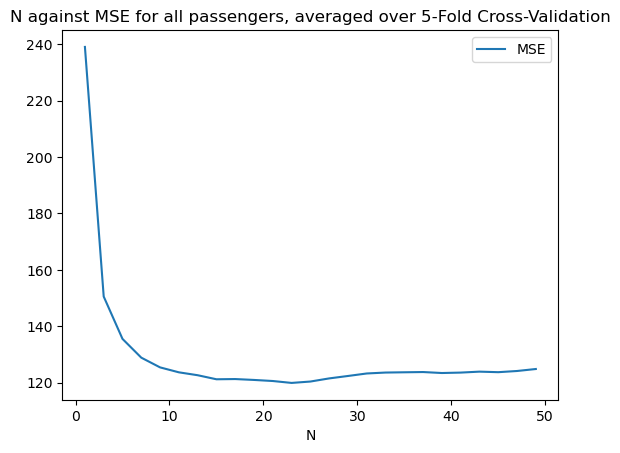

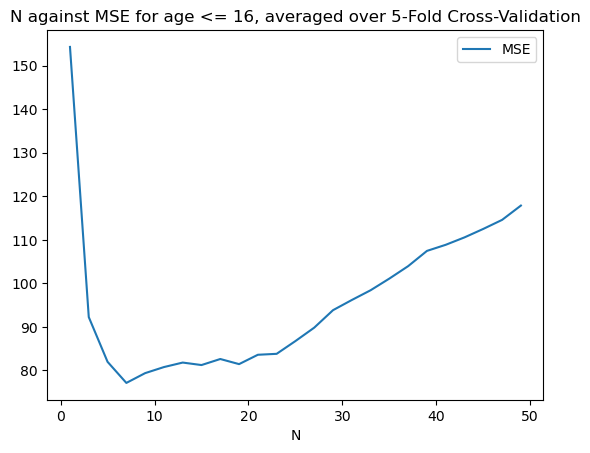

In [41]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import KFold

# Get all entries with non-NaN age data, from both labelled (for survival) data and unlabelled (for survival) data
# We won't use this model to actually impute the ages (otherwise there would be data leak) - only to determine the optimal N
age_total_data = pd.concat([clean_labelled_data.drop("Survived", axis = 1), clean_unlabelled_data], axis=0)
age_labelled_data = age_total_data.dropna(subset = "Age")

# Setting up the K-Fold splitter
K = 5
kf = KFold(n_splits = K, shuffle = True, random_state = 1)

# Iterate through the train test splits
N_values = np.arange(1,50,2)
results = {N : [] for N in N_values}
results_kids = {N : [] for N in N_values}
for train_indices, test_indices in kf.split(age_labelled_data):
    # Reading the training and testing data
    train_data = age_labelled_data.iloc[train_indices].copy(deep = True)
    test_data = age_labelled_data.iloc[test_indices].copy(deep = True)
    # Extract the data for kids, as the accuracies of their age estimations are more important
    test_data_kids = test_data[test_data["Age"] <= 16].copy(deep = True)

    # Masking the true ages in testing data, and making a copy beforehand
    y_true_ages = test_data["Age"].copy(deep = True)
    test_data["Age"] = np.nan
    y_true_ages_kids = test_data_kids["Age"].copy(deep = True)
    test_data_kids["Age"] = np.nan
    
    # Normalise the data
    scaler = MinMaxScaler().set_output(transform="pandas")
    train_data_scaled = scaler.fit_transform(train_data)
    test_data_scaled = scaler.transform(test_data)
    test_data_kids_scaled = scaler.transform(test_data_kids)

    # Iterate through the values of N and take note of their performance (i.e. the mean-squared-errors)
    for N in N_values:
        imputer = KNNImputer(n_neighbors = N).set_output(transform="pandas")
        imputer.fit(train_data_scaled)
        test_data_scaled_imputed = imputer.transform(test_data_scaled)
        test_data_imputed = scaler.inverse_transform(test_data_scaled_imputed)
        # Since we use K-Fold splitting, we need to put index = test_data.index to restore the index info lost in
        # the scaler.inverse_transform() function which returns an np array without those labaels
        y_predicted_ages = pd.DataFrame(test_data_imputed, columns = test_data.columns, index = test_data.index)["Age"]
        mse = np.mean((y_true_ages - y_predicted_ages) ** 2)
        results[N].append(mse)
        # kids
        test_data_kids_scaled_imputed = imputer.transform(test_data_kids_scaled)
        test_data_kids_imputed = scaler.inverse_transform(test_data_kids_scaled_imputed)
        # Since we use K-Fold splitting, we need to put index = test_data.index to restore the index info lost in
        # the scaler.inverse_transform() function which returns an np array without those labaels
        y_predicted_ages_kids = pd.DataFrame(test_data_kids_imputed, columns = test_data_kids.columns, index = test_data_kids.index)["Age"]
        mse = np.mean((y_true_ages_kids - y_predicted_ages_kids) ** 2)
        results_kids[N].append(mse)

average_results = {N : np.mean(mses) for N,mses in results.items()}

average_results = pd.DataFrame({"N" : average_results.keys(), "MSE" : average_results.values()})
average_results.plot.line("N", "MSE", title = "N against MSE for all passengers, averaged over " + str(K) + "-Fold Cross-Validation")

average_results_kids = {N : np.mean(mses) for N,mses in results_kids.items()}

average_results_kids = pd.DataFrame({"N" : average_results_kids.keys(), "MSE" : average_results_kids.values()})
average_results_kids.plot.line("N", "MSE", title = "N against MSE for age <= 16, averaged over " + str(K) + "-Fold Cross-Validation")

For all passengers, the model predicts well for $15 \leq N \leq 23$. For kids, the model predicts well for $7 \leq N \leq 19$. We therefore choose $N = 19$, the largest number in both ranges to minimise overfitting.

In [42]:
# Defining the data variables used in this section
logistic_labelled = clean_labelled_data.copy(deep = True)
logistic_labelled_X = logistic_labelled.drop("Survived", axis = 1)
logistic_labelled_y = logistic_labelled["Survived"]
logistic_unlabelled_X = clean_unlabelled_data.copy(deep = True)

Imputing missing age values:

In [43]:
N = 19

scaler = MinMaxScaler().set_output(transform="pandas")
imputer = KNNImputer(n_neighbors = N).set_output(transform="pandas")

# Training KNN on normalised data
age_total_data = pd.concat([logistic_labelled_X, logistic_unlabelled_X], axis=0)
age_train_data = age_total_data.dropna(subset = "Age")
age_train_data_scaled = scaler.fit_transform(age_train_data)
imputer.fit(age_train_data_scaled)

# Impute and undo the scaling
logistic_labelled_X_scaled = scaler.transform(logistic_labelled_X)
logistic_labelled_X_scaled_imputed = imputer.transform(logistic_labelled_X_scaled)
logistic_labelled_X_imputed = pd.DataFrame(scaler.inverse_transform(logistic_labelled_X_scaled_imputed), columns = logistic_labelled_X.columns)

logistic_unlabelled_X_scaled = scaler.transform(logistic_unlabelled_X)
logistic_unlabelled_X_scaled_imputed = imputer.transform(logistic_unlabelled_X_scaled)
logistic_unlabelled_X_imputed = pd.DataFrame(scaler.inverse_transform(logistic_unlabelled_X_scaled_imputed), columns = logistic_unlabelled_X.columns)

logistic_labelled_imputed = pd.concat([logistic_labelled_X_imputed,logistic_labelled_y], axis = 1)

print("Imputed labelled data NaN counts:")
print(logistic_labelled_imputed.isnull().sum())

Imputed labelled data NaN counts:
Pclass           0
Dr               0
Master           0
Military         0
Miss             0
Mr               0
Mrs              0
Rev              0
IsFemale         0
Age              0
LogFamilySize    0
LogAvgFare       0
C                0
Q                0
Survived         0
dtype: int64


With all data cleaning done, we are now ready for inference.

### Inference with logistic regression:

Let us firstly experiment with the best regularisation parameter $C$ used in sklearn.linear_model.LogisticRegression. The value of $C$ is the inverse of the regularisation strength, so a greater value of $C$ indicates weaker regularisation.

Error will be measured buy the fraction of wrong predictions.

<Axes: title={'center': 'C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)'}, xlabel='C'>

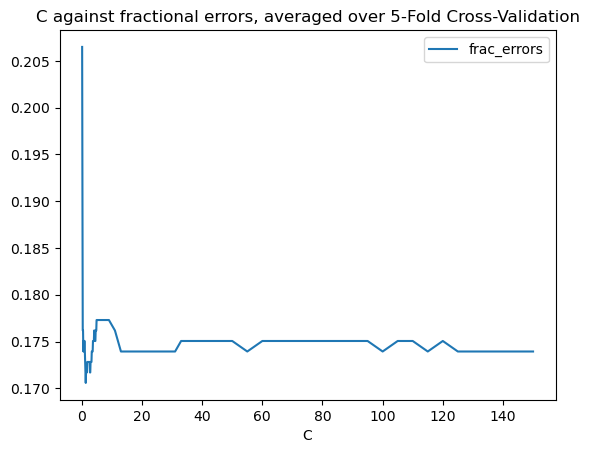

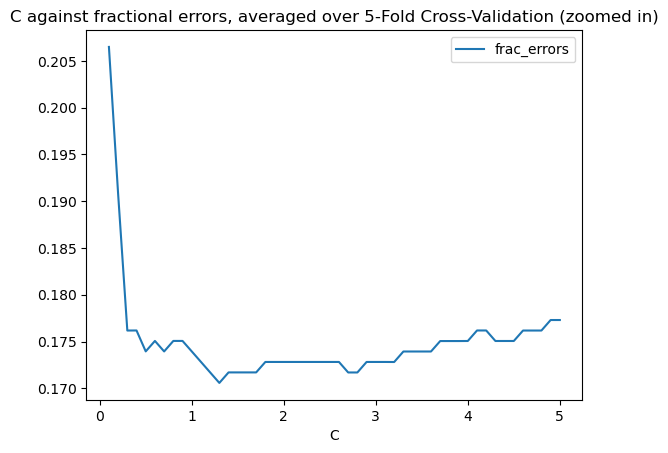

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

# Load training data and testing data
train = logistic_labelled_imputed.copy(deep = False)

# Creating K-Fold splitter
K = 5
kf = KFold(n_splits = K, shuffle = True, random_state = 1)

# Setting up values of C (the regularisation parameter) to try
C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0), np.arange(50,150.05,5)])
results = {C : [] for C in C_values}

for kf_train_indices, kf_test_indices in kf.split(train):
    kf_train = train.iloc[kf_train_indices].copy(deep = True)
    kf_test = train.iloc[kf_test_indices].copy(deep = True)

    kf_train_X = kf_train.drop("Survived", axis = 1)
    kf_train_y = kf_train["Survived"]
    kf_test_X = kf_test.drop("Survived", axis = 1)
    kf_test_y = kf_test["Survived"]

    # Scaling the training and testing data
    scaler = MinMaxScaler().set_output(transform="pandas")
    kf_train_X_scaled = scaler.fit_transform(kf_train_X)
    kf_test_X_scaled = scaler.transform(kf_test_X)

    # Iterate through the regularasition parameter C to find the best regularisation strength
    for C in C_values:
        # Fit a logistic regression model
        model = LogisticRegression(C=C)
        model.fit(kf_train_X_scaled, kf_train_y)
        
        # Predict the survival outcomes on test data
        y_pred = model.predict(kf_test_X_scaled)

        # Calculate the fractional error
        mismatches = (kf_test_y != y_pred).sum()
        frac_error = float(mismatches) / len(kf_test_y)
        results[C].append(frac_error)

average_results = {C : np.mean(frac_errors) for C,frac_errors in results.items()}

average_results = pd.DataFrame({"C" : average_results.keys(), "frac_errors" : average_results.values()})
average_results.plot.line("C", "frac_errors", title = "C against fractional errors, averaged over " + str(K) + "-Fold Cross-Validation")



first_thirty_results = {C : np.mean(frac_errors) for C, frac_errors in sorted(results.items())[:50]}

first_thirty_results = pd.DataFrame({"C" : first_thirty_results.keys(), "frac_errors" : first_thirty_results.values()})
first_thirty_results.plot.line("C", "frac_errors", title = "C against fractional errors, averaged over " + str(K) + "-Fold Cross-Validation (zoomed in)")

Seems like the errors are not much bigger than the minimum error with low regularisation. This means the model is unable to dramatically overfit, sugeesting that we could try a more complicated model, for example logistic regression with polynomial features.

For now, we make predictions using logistic regression with $C = 1.3$, and with all entries with missing Age values removed:

In [45]:
from sklearn.linear_model import LogisticRegression

C = 1.3

# Load training data and testing data
labelled_X = logistic_labelled_X_imputed
labelled_y = logistic_labelled_y
unlabelled_X = logistic_unlabelled_X_imputed

# Scaling the training and testing data
scaler = MinMaxScaler().set_output(transform="pandas")
labelled_X_scaled = scaler.fit_transform(labelled_X)
unlabelled_X_scaled = scaler.transform(unlabelled_X)

# Fit a logistic regression model
model = LogisticRegression(C=C)
model.fit(labelled_X_scaled, labelled_y)

# Predict the survival outcomes
y_pred = model.predict(unlabelled_X_scaled)

# Save to DataFrame
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/logistic_imputed_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


This gives a score of 0.77272 on Kaggle. For reference, a simple predicition having all female passengers predicted to survive and all male passengers predicted to not survive give a score of 0.76555. I guess we are doing a little better than a simple guess!

### Inference with logistic regression and polynomial features

Let us try again with polynomial features.

This time I will try implementing an sklearn Pipeline for the model and GridSearchCV (instead of manual K-Fold Cross-Validation loops) for finding the best regularisation parameter.

Training and fitting the model:

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Load training data and testing data
train_X = logistic_labelled_X_imputed.copy(deep = False)
train_y = logistic_labelled_y.copy(deep = False)

DEGREE = 2
MAX_ITER = 1000
# Create pipeline model
log_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree = DEGREE, include_bias = False)), # bias will be added by LogisticRegression
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("logreg", LogisticRegression(max_iter = MAX_ITER)),
])

# Create parameter grid
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0), np.arange(50,150.05,5)]) 
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0)])
C_values = np.concatenate([np.arange(1.0,49.05,1.0), np.arange(50.0,150.05,2.0)])
param_grid = {"logreg__C" : C_values}

# Create and fit GridSearchCV
grid_search_cv = GridSearchCV(log_poly_model, param_grid, scoring = "accuracy")
grid_search_cv.fit(train_X, train_y)

#average_results = {C : np.mean(frac_errors) for C,frac_errors in results.items()}

#average_results = pd.DataFrame({"C" : average_results.keys(), "frac_errors" : average_results.values()})
#average_results.plot.line("C", "frac_errors", title = "C against fractional errors, averaged over " + str(K) + "-Fold Cross-Validation")



#first_thirty_results = {C : np.mean(frac_errors) for C, frac_errors in sorted(results.items())[:50]}

#first_thirty_results = pd.DataFrame({"C" : first_thirty_results.keys(), "frac_errors" : first_thirty_results.values()})
#first_thirty_results.plot.line("C", "frac_errors", title = "C against fractional errors, averaged over " + str(K) + "-Fold Cross-Validation (zoomed in)")

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'logreg__C': array([ 1., ... 150.])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,2


Plotting the regularisation parameter against fractional errors:

<Axes: title={'center': 'C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)'}, xlabel='param_logreg__C'>

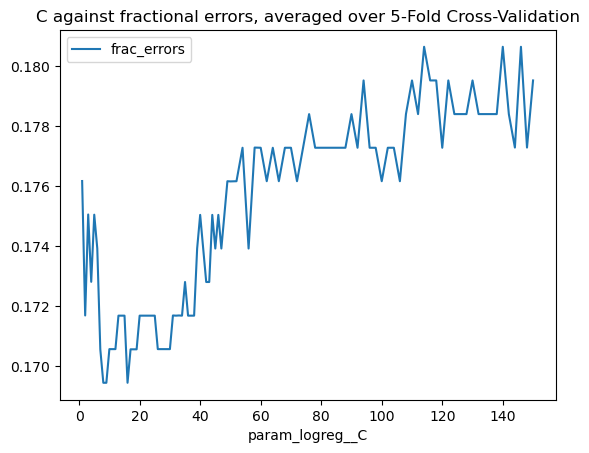

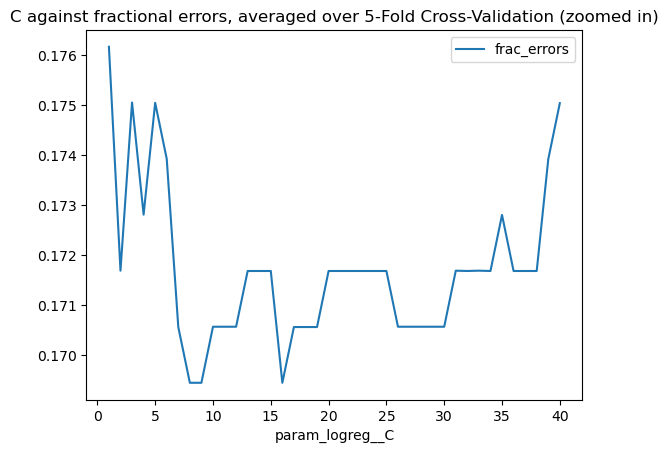

In [47]:
results = pd.DataFrame(grid_search_cv.cv_results_)
results["frac_errors"] = 1 - results["mean_test_score"]
results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation")

first_results = pd.DataFrame({"param_logreg__C" : results["param_logreg__C"][:40], "frac_errors" : results["frac_errors"][:40]})
first_results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)")

Make predictions!

In [48]:
# Load testing data
unlabelled_X = logistic_unlabelled_X_imputed

# Predict the survival outcomes
y_pred = grid_search_cv.predict(unlabelled_X)

# Save to DataFrame
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/log_poly_imputed_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


This achieved a score of 0.77033 - a little bit worse, but not by much. This indicates that a linear model is as capable as a (simple) polynomial model in capturing the relationships in our dataset.

### Inference with logistic regression and fewer features:

Since adding features didn't work, perhaps removing the less relevant features would be helpful.

Let us have a look at the features in our cleaned labelled data:

In [49]:
print(clean_labelled_data.head())

   Survived  Pclass  Dr  Master  Military  Miss  Mr  Mrs  Rev  IsFemale   Age  \
0         0       3   0       0         0     0   1    0    0         0  22.0   
1         1       1   0       0         0     0   0    1    0         1  38.0   
2         1       3   0       0         0     1   0    0    0         1  26.0   
3         1       1   0       0         0     0   0    1    0         1  35.0   
4         0       3   0       0         0     0   1    0    0         0  35.0   

   LogFamilySize  LogAvgFare  C  Q  
0       0.693147    2.110213  0  0  
1       0.693147    3.601186  1  0  
2       0.000000    2.188856  0  0  
3       0.693147    3.316003  0  0  
4       0.000000    2.202765  0  0  


We know that there are clear correlations between the survival rate and gender, ticket class, family size, average fare.

For age, whilst there are correlations, the relationship doesn't seem strong besides for very young kids. Also, we had to estimate a lot of ages, which were not very accurate (with a variance of $120$), which could have added noise.

The embarking port did seem to show a correlation, but it could be due to confounding factors, such as having more male passengers in the ports with lower survival rates.

The large number of titles were quite unnecessary. We can remove the rare ones (Dr, Military, Rev) and keep only the common ones (Master, Mr, Mrs, Miss).

In [50]:
smaller_clean_labelled_data = logistic_labelled_imputed[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare"]]
smaller_clean_unlabelled_data = logistic_unlabelled_X_imputed[["Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare"]]

And now we train a simple logistic regression model!

<Axes: title={'center': 'C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)'}, xlabel='param_logreg__C'>

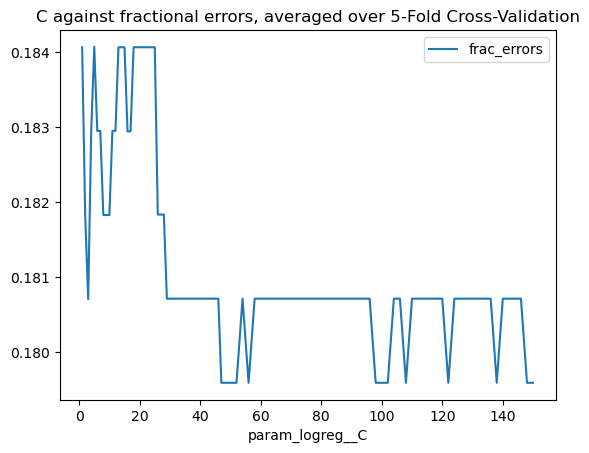

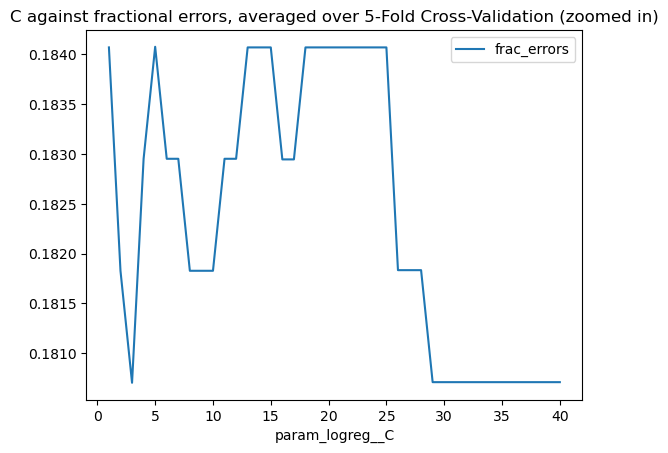

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Load training data
labelled_X = smaller_clean_labelled_data.drop("Survived", axis = 1)
labelled_y = smaller_clean_labelled_data["Survived"].copy(deep = False)

# Create pipeline model
log_poly_model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("logreg", LogisticRegression()),
])

# Create parameter grid
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0), np.arange(50,150.05,5)]) 
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0)])
C_values = np.concatenate([np.arange(1.0,49.05,1.0), np.arange(50.0,150.05,2.0)])
param_grid = {"logreg__C" : C_values}

# Create and fit GridSearchCV
grid_search_cv_2 = GridSearchCV(log_poly_model, param_grid, scoring = "accuracy")
grid_search_cv_2.fit(labelled_X, labelled_y)

# Display graph of C against errors
results = pd.DataFrame(grid_search_cv_2.cv_results_)
results["frac_errors"] = 1 - results["mean_test_score"]
results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation")

first_results = pd.DataFrame({"param_logreg__C" : results["param_logreg__C"][:40], "frac_errors" : results["frac_errors"][:40]})
first_results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)")

In [52]:
# Load testing data
unlabelled_X = smaller_clean_unlabelled_data.copy(deep = False)

# Predict the survival outcomes
y_pred = grid_search_cv_2.predict(unlabelled_X)

# Save to DataFrame
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/log_fewerfeatures_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


A score of 0.76794.

With some trail and errors, the features that gave the highest score is by adding age to my previous selection.

In [53]:
smaller_clean_labelled_data = logistic_labelled_imputed[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]].copy(deep = True)
smaller_clean_unlabelled_data = logistic_unlabelled_X_imputed[["Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]].copy(deep = True)

<Axes: title={'center': 'C against fractional errors, averaged over 5-Fold Cross-Validation'}, xlabel='param_logreg__C'>

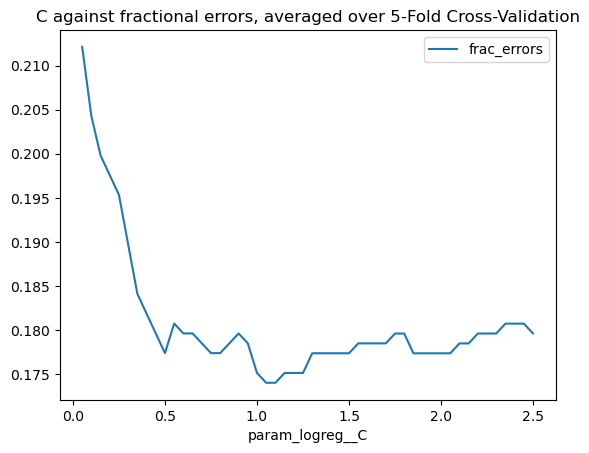

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Load training data
labelled_X = smaller_clean_labelled_data.drop("Survived", axis = 1)
labelled_y = smaller_clean_labelled_data["Survived"].copy(deep = False)

# Create pipeline model
log_poly_model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("logreg", LogisticRegression()),
])

# Create parameter grid
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0), np.arange(50,150.05,5)]) 
#C_values = np.concatenate([np.arange(0.1,4.95,0.1), np.arange(5.0,49.05,2.0)])
C_values = np.arange(0.05,2.5005,0.05)
param_grid = {"logreg__C" : C_values}

# Create and fit GridSearchCV
grid_search_cv_3 = GridSearchCV(log_poly_model, param_grid, scoring = "accuracy")
grid_search_cv_3.fit(labelled_X, labelled_y)

# Display graph of C against errors
results = pd.DataFrame(grid_search_cv_3.cv_results_)
results["frac_errors"] = 1 - results["mean_test_score"]
results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation")

#first_results = pd.DataFrame({"param_logreg__C" : results["param_logreg__C"][:40], "frac_errors" : results["frac_errors"][:40]})
#first_results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation (zoomed in)")

In [55]:
# Load testing data
unlabelled_X = smaller_clean_unlabelled_data.copy(deep = False)

# Predict the survival outcomes
y_pred = grid_search_cv_3.predict(unlabelled_X)

# Save to DataFrame
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/log_fewerfeatures_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


This gives a score of 0.78229.

__Data leak review:__

After a review I found a data leak by imputing with KNN before using on K-Fold Cross-Validation on the actual prediction model. Below is a version with no data leaks. (Results read from file due to long running time.)

In [57]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV

# Loading the cleaned data with some missing Age values
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Defining the model
model = Pipeline([
    ("KNN", KNNImputer()),
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("logreg", LogisticRegression()),
])

# Defining the GridSearchCV object
N_values = np.arange(1,30,2)
C_values = np.arange(0.1,3.05,0.1)
param_grid = {
    "KNN__n_neighbors" : N_values,
    "logreg__C" : C_values,
}
grid_search_cv_4 = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_4.fit(temp_labelled_data_X,temp_labelled_data_y)

#results = pd.DataFrame(grid_search_cv_4.cv_results_)
#results["frac_errors"] = 1 - results["mean_test_score"]
#results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation")
#results.plot.line("param_KNN__n_neighbors", "frac_errors", title = "N against fractional errors, averaged over 5-Fold Cross-Validation")


Exception: This cell is intentionally disabled due to long compute time.

In [58]:
results_file_path = "./results/LogisticRegressionGridSearchCV.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_logreg__C","frac_error"]].copy(deep = False)
results_sorted[:5]

,param_KNN__n_neighbors,param_logreg__C,frac_error
400,27,1.1,0.172858
370,25,1.1,0.172858
340,23,1.1,0.172864
339,23,1.0,0.172864
280,19,1.1,0.172864


We choose $N=25$ and $C = 1.1$ in our model.

In [59]:
# Load training and testing data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data[["Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer(n_neighbors = 25)),
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("logreg", LogisticRegression(C = 1.1)),
])

#Fit the model
model.fit(temp_labelled_data_X,temp_labelled_data_y)

# Predict the survival outcomes
y_pred = model.predict(temp_unlabelled_data_X)

# Save to DataFrame
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/log_no_leak_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


A Kaggle score of 0.77990.

---

## Tree models:

A regression tree $F : \Omega \to \mathbb{R}$ is a step function taking the form

$$F(x) = \sum_{k=1}^K \gamma_k I(x \in R_k)$$

where $K$ is the number of leaves, $(R_k)_{k=1}^K$ are the subsets of $\Omega$ corresponding to the leaves (which form a partition of the population $\Omega$), and $(\gamma_k)_{k=1}^K$ are the prediction values corresponding to the leaves.

The training a regression tree is the process of constructing a tree where branchings are conditioned on the features, where the final construction gives a partition $(R_k)_{k=1}^K$ of $\Omega$ and corresponding values $(\gamma_k)_{k=1}^K$ which hopefully reduce the loss as much as possible.

There are many ways a regression tree can be constructed. The most standard one branches based on minimising MSE. However, since the branching condition only optimises for the next branch, this is a "greedy" algorithm that naturally causes a high variance in the model. A slight change of entries (rows in dataset) could cause a different branching early on, which in turn causes a huge difference in the final tree structure.

A collection of trees, called a forest, can be used to average out the variance. By choosing a random set of entries and a random subset of features for each tree's training process, and aggregating the predictions of trees by taking their mean, will give a much more reliable result with a much lower variance.

To train (binary) classification trees, we change the branching condition to be based on measures like Gini impurity or entropy, let the trees predict the categories, and aggregate the results by taking the mode.

A more advanced method called gradient boosting takes account of the loss function by using its gradient in the construction of trees. The final prediction is aggregated by taking the sum of all trees, where each new tree tries to reduce the loss by moving along the negative gradient of the loss function.

In this section we experiment with a number of models. Let us begin with sklearn.ensemble.RandomForestClassifier.

### Random Classification Forest

In a random classification forest, each tree is constructed as follows:

1. Randomly select a collection of entries with replacement called the bootstrap sample, and a subset of features without replacement.
2. For each branching, iterate through the features and possible splits of each feature to determine the binary split that produces the lowest Gini impurity or entropy.
3. Repeat step 2 until all samples in a subset are of the same category, or some terminating conditions (e.g. maximum depth, minimum number of samples per leaf) are met.


Unlike linear and polynomial models, for trees we don't need to scale the features. We create a pipeline with KNN imputer to impute the missing ages, and then feed the data straight into a random forest.

We use GridSearchCV to find the optimal parameters for
- N;
- max tree depth;
- minimum samples in each leaf;
- maximum number of features selected for each tree.

(Results read from file due to long running time.)

In [60]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer

# Load training data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer()),
    ("random_forest", RandomForestClassifier(random_state = 1))
])

# Create the param grid
N_values = [5,10,15,20]
max_depth_values = [4,6,8,10,12,14,16,18,20]
min_samples_leaf_values = [1,3,5,7,9,11,13,15,17,19]
max_features_values = ["sqrt", None]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "random_forest__max_depth" : max_depth_values,
    "random_forest__min_samples_leaf" : min_samples_leaf_values,
    "random_forest__max_features" : max_features_values,
}

# Create and fit GridSearchCV
grid_search_cv_rf = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_rf.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

Let us probe our results a little.

Firstly, we have a look at the best-performing set of paramaters:

In [61]:
results_file_path = "./results/RandomForestClassifierGridSearchCV.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_random_forest__max_depth","param_random_forest__max_features","param_random_forest__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_random_forest__max_depth,param_random_forest__max_features,param_random_forest__min_samples_leaf,frac_error
34,5,6,NaN,9,0.148133
114,5,14,NaN,9,0.149256
154,5,18,NaN,9,0.149256
134,5,16,NaN,9,0.149256
94,5,12,NaN,9,0.149256
174,5,20,NaN,9,0.149256
214,10,6,NaN,9,0.150373
54,5,8,NaN,9,0.150373
74,5,10,NaN,9,0.150373
574,20,6,NaN,9,0.150380


It seems like the choices _max_features = None, min_samples_leaf = $9$_ are consistently good.

The best parameters for n_neighbours and max_depth seem to have higher variances. Let us plot a 2D heatmap to illustrate the pattern:

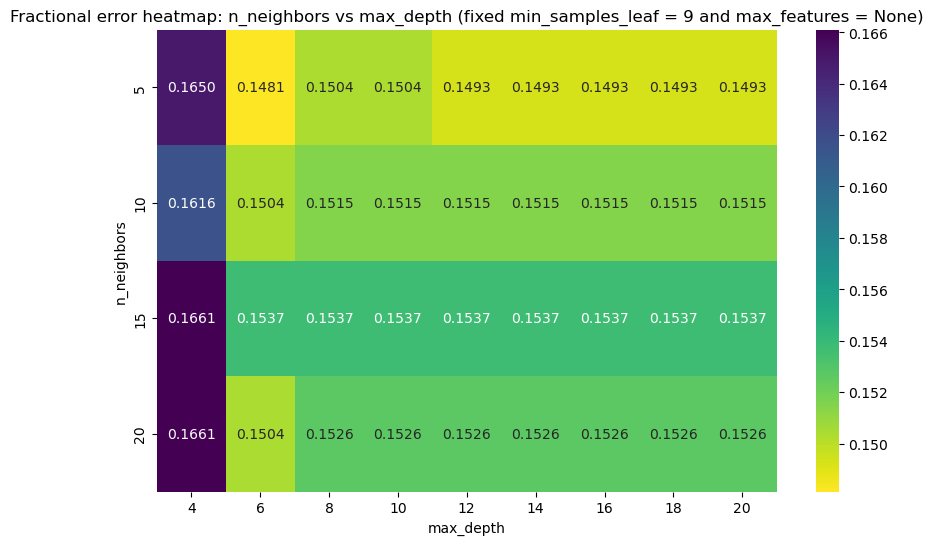

In [62]:
import seaborn as sns

# Fixing max_features = None and min_samples_leaf = 9
fixed_params_results = results[
    (results["param_random_forest__max_features"].isna()) & 
    (results["param_random_forest__min_samples_leaf"] == 9)
].copy(deep = False)

# Extracting heatmap data
heatmap_data = fixed_params_results.pivot(
    index="param_KNN__n_neighbors", 
    columns="param_random_forest__max_depth", 
    values="frac_error"
)

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="viridis_r", fmt=".4f")
plt.title("Fractional error heatmap: n_neighbors vs max_depth (fixed min_samples_leaf = 9 and max_features = None)")
plt.xlabel("max_depth")
plt.ylabel("n_neighbors")
plt.show()

The heatmap suggests that max_depth is not very revelant above $10$ for $n\_neighbors \neq 5$. This is most likely because the higher depths are not needed, especially with higher n_neighbors making many passengers' data closer to the mean.

On the other hand, for the set of parameters with max_features = sqrt, the best-perfoming sets of parameters are:

In [63]:
results_sqrt_features = results[results["param_random_forest__max_features"] == "sqrt"][["param_KNN__n_neighbors","param_random_forest__max_depth","param_random_forest__max_features","param_random_forest__min_samples_leaf","frac_error"]].copy(deep = False)
results_sqrt_features_sorted = results_sqrt_features.sort_values("frac_error")
results_sqrt_features_sorted[:20]

,param_KNN__n_neighbors,param_random_forest__max_depth,param_random_forest__max_features,param_random_forest__min_samples_leaf,frac_error
101,5,14,sqrt,3,0.157121
81,5,12,sqrt,3,0.158245
161,5,20,sqrt,3,0.158251
141,5,18,sqrt,3,0.159375
261,10,12,sqrt,3,0.160473
322,10,18,sqrt,5,0.160486
302,10,16,sqrt,5,0.160486
342,10,20,sqrt,5,0.160486
41,5,8,sqrt,3,0.160486
600,20,10,sqrt,1,0.160492


In this case the best min_samples_leaf is usually $3$. Again, we fix max_features to "sqrt" and min_samples_leaf to $3$ and inspect the heatmap:

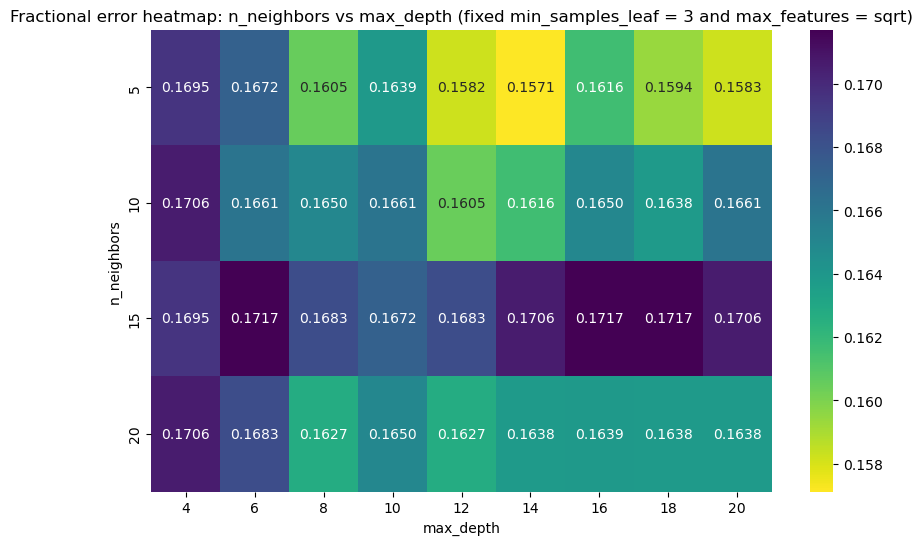

In [64]:
import seaborn as sns

# Fixing max_features = None and min_samples_leaf = 9
fixed_params_results = results[
    (results["param_random_forest__max_features"] == "sqrt") & 
    (results["param_random_forest__min_samples_leaf"] == 3)
].copy(deep = False)

# Extracting heatmap data
heatmap_data = fixed_params_results.pivot(
    index="param_KNN__n_neighbors", 
    columns="param_random_forest__max_depth", 
    values="frac_error"
)

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="viridis_r", fmt=".4f")
plt.title("Fractional error heatmap: n_neighbors vs max_depth (fixed min_samples_leaf = 3 and max_features = sqrt)")
plt.xlabel("max_depth")
plt.ylabel("n_neighbors")
plt.show()

In this case a higher depth and smaller min_samples_leaf perform better, since the number of features is limited per split.

We will finely optimise the parameters for the case max_features = None, by carrying out GridSearchCV with a much smaller range for parameters:

(Results read from file due to long running time.)

In [65]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer

# Load training data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer()),
    ("random_forest", RandomForestClassifier(random_state = 1))
])

# Create the param grid
N_values = [1,3,5,7]
max_depth_values = [4,6,8,10]
min_samples_leaf_values = [7,9,11,13]
max_features_values = [None]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "random_forest__max_depth" : max_depth_values,
    "random_forest__min_samples_leaf" : min_samples_leaf_values,
    "random_forest__max_features" : max_features_values,
}

# Create and fit GridSearchCV
grid_search_cv_rf_fine = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_rf_fine.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [66]:
results_file_path = "./results/RandomForestClassifierGridSearchCVFine.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_random_forest__max_depth","param_random_forest__max_features","param_random_forest__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_random_forest__max_depth,param_random_forest__max_features,param_random_forest__min_samples_leaf,frac_error
37,5,6,NaN,9,0.148133
41,5,8,NaN,9,0.150373
45,5,10,NaN,9,0.150373
46,5,10,NaN,11,0.152627
57,7,8,NaN,9,0.152627
42,5,8,NaN,11,0.152627
38,5,6,NaN,11,0.153751
61,7,10,NaN,9,0.153751
53,7,6,NaN,9,0.153757
58,7,8,NaN,11,0.154880


The same set of parameters still give the best results. We will then create and fit our model with parameters:
- n_neighbors = 5
- max_depth = 6
- min_samples_leaf = 9
- max_features = None

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

# Load training and testing data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data[["Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer(n_neighbors = 5)),
    ("random_forest", RandomForestClassifier(max_features = None, max_depth = 6, min_samples_leaf = 9, random_state = 1))
])

# Fit the model
model.fit(temp_labelled_data_X, temp_labelled_data_y)

# Make predictions!
y_pred = model.predict(temp_unlabelled_data_X)

# Save predictions to file
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/random_forest_imputed_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


This gives a Kaggle score of 0.76794.

### Gradient Boosted Forest

A gradient boosted forest predicts the output by taking the sum of the trees, scaled by a learning rate coefficient. Such a forest $F : \Omega \to \mathbb{R}$ is defined by the recursive formula

$$F_m(x) = F_{m-1}(x) + \nu \sum_{k=1}^{K_m} \gamma_{mk} I(x \in R_{mk})$$

for $m = 0$ to $M$, the number of trees in the forest. The symbol $\nu \in (0,1]$ denotes the learning rate, $K_m \in \mathbb{N}$ denotes the number of leaves in the $m$-th tree, $\gamma_{mk} \in \mathbb{R}$ and $R_{mk} \subseteq \Omega$ denote the value and the conditions corresponding to the $k$-th leaf in the $m$-th tree.

The tree $F_0$ is simply a constant function $F_0(x) := \text{argmin}_{\gamma \in \mathbb{R}} \sum_{i=1}^n L(y_i, \gamma)$ minimising the loss. We used $(x_i,y_i)_{i=1}^n$ to denote the set of data, $L(y_i, F(x_i)) = -y_i \log(\sigma(F(x_i)))) - (1-y_i) \log(1-\sigma(F(x_i)))$ to denote the negative log likelihood loss function, where $\sigma(x) = \frac{1}{1-e^{-x}}$ is the logistic function.

We interpret the outputs of functions $(F_m)_{m=1}^M$ to be the _log odds_. The probability $p_{mi}$ of the $i$-th entry of the $m$-th tree is obtained by passing through the logistic function, i.e. $p_{mi} = \sigma(F_m(x_i)) = \frac{1}{1+e^{-F_m(x_i)}}$.

For $m=1$ to $M$, we construct trees as follows:

1. Calculate the pseudo-residuals $r_{(m-1)i} := - \frac{\partial L (y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)}$ for $i = 1$ to $n$, which always point in the direction that reduces the loss. For this specific loss function, the negative derivative scales linearly with the distance to the correct prediction.

2. Fit a usual regression tree to the $r_{(m-1)i}$ values, obtaining subsets $(R_{mk})_{k=1}^{K_m}$ partitioning the sample space $\Omega$.

3. For each leaf index $k = 1$ to $K_m$, calculate $\gamma_{mk} := \text{argmin}_\gamma \sum_{x_i \in R_{mk}} L(y_i, F_{m-1}(x_i) + \gamma)$, which is the prediction value of the leaf. Since a leaf tend to contain similar pseudo-residuals, finding such a $\gamma_{mk}$ is expected to reduce the overall loss for this leaf, since it mostly follows the negative gradient.

4. Update $F_m(x) = F_{m-1}(x) + \nu \sum_{k=1}^{K_m} \gamma_{mk} I(x \in R_{mk})$.

The final function $F_M$ is our model, which predicts the log-odds. The final probability predictions are given by $\sigma(F_M(x))$.

We note that some expressions have closed-form formulae:
- $F_0(x) := \text{argmin}_{\gamma \in \mathbb{R}} \sum_{i=1}^n L(y_i, \gamma) = \log \left( \frac{Y}{n-Y} \right)$ where $Y = \sum_{i=1}^n$ is the number of positive samples;
- $L(y_i, F_m(x_i))$ can be simplified to $-y F_m(x) + \log (1+e^{F_m(x)})$, therefore $- \frac{\partial L(y_i, F_m(x_i))}{\partial F_m(x_i)}$ can be evaluated and simplified to $\sigma(F_m(x_i)) - y_i$, or equivalently $p_{mi} - y_i$.
- For $\gamma_{mk} := \text{argmin}_\gamma \sum_{x_i \in R_{mk}} L(y_i, F_{m-1}(x_i) + \gamma)$, the expression can be approximated by a second order Taylor expansion whose minimum in achieved by $\gamma = \frac{\sum_{x_i \in R_{mk}} r_{(m-1)i}}{\sum_{x_i \in R_{mk}} p_{(m-1)i}(1-p_{(m-1)i})}$.

In our implementation, we don't explicitly code all these steps. We use the sklearn.ensemble.GradientBoostingClassifier class which is implemented as described above. Firstly we use GridSearchCV to find the best hyperparameters. The top 20 sets of hyperparamters will be displayed.

(Results read from file due to long running time.)

In [68]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer

# Load training data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [5,10,20]
n_estimators = [50,100,200]
learning_rates = [0.01,0.05,0.1,0.2,0.3]
max_depths = [2,3,4,5]
min_samples_leaf_values = [5,10,20]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [69]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCV.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
282,10,50,0.10,5,10,0.149256
431,20,200,0.05,5,20,0.149281
285,10,50,0.10,5,20,0.150380
31,5,100,0.01,5,10,0.150392
56,5,200,0.05,4,5,0.150405
98,5,200,0.10,4,20,0.150405
250,10,100,0.05,5,20,0.151510
274,10,100,0.10,4,10,0.151516
124,5,100,0.20,3,20,0.151535
247,10,100,0.05,5,10,0.152627


Looking at our coarse parameter search results, we observe that:
- A lower learning rate of $0.05$ or $0.10$ tend to out-perform higher learning rates;
- A max tree depth of $5$ is dominant, perhaps a max depth of $6$ is useful;
- A minimum samples in each leaf of $10$ or $20$ is dominant.

Now let us search again with a finer grid of parameters:

In [70]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer

# Load training data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [5,10,20]
n_estimators = [50,100,200]
learning_rates = [0.025,0.05,0.075,0.1]
max_depths = [4,5,6]
min_samples_leaf_values = [10,20,30]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [71]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCVFine.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
67,5,100,0.075,5,20,0.147028
239,20,200,0.025,6,20,0.148151
198,10,50,0.100,5,10,0.149256
49,5,100,0.050,6,20,0.149262
106,5,100,0.100,6,30,0.149262
257,20,200,0.050,5,20,0.149281
158,10,200,0.050,6,20,0.150380
201,10,50,0.100,5,20,0.150380
175,10,100,0.075,5,20,0.150392
86,5,200,0.100,4,20,0.150405


Let us carry out one more refined search near n_estimators = 100 and learning_rate = 0.075.

In [72]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer

# Load training data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [5,10,15,20]
n_estimators = [80,90,100,110,120]
learning_rates = [0.065,0.07,0.075,0.08,0.085,0.09]
max_depths = [5,6]
min_samples_leaf_values = [16,18,20,22,24]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [73]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCVFine_2.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
451,10,90,0.080,5,16,0.143651
309,10,120,0.065,5,18,0.144774
308,10,110,0.065,5,18,0.145898
507,10,100,0.085,5,18,0.145904
202,5,100,0.085,5,16,0.145910
203,5,110,0.085,5,16,0.145910
400,10,80,0.075,5,16,0.147003
550,10,80,0.090,5,16,0.147015
1100,20,80,0.085,5,16,0.147015
303,10,110,0.065,5,16,0.147015


We will use the following paramters for our final model:
- n_neighbors = 10
- n_estimators = 90
- learning rate = 0.080
- max_depth = 5
- min_samples_leaf = 16

In [74]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer

# Load training and testing data
temp_labelled_data = clean_labelled_data[["Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data[["Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age"]]

# Create the pipeline
model = Pipeline([
    ("KNN", KNNImputer(n_neighbors = 10)),
    ("gbc", GradientBoostingClassifier(n_estimators = 90, learning_rate = 0.080, max_depth = 5, min_samples_leaf = 16, random_state = 1))
])

# Fit the model
model.fit(temp_labelled_data_X, temp_labelled_data_y)

# Make predictions!
y_pred = model.predict(temp_unlabelled_data_X)

# Save predictions to file
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/gbc_imputed_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


This gives a kaggle score of 0.75119.

---

__Update:__

To reduce the error, we carry out one more data analysis: for each ticket with multiple ticket holders, how well are their survivals correlated?

Since the survival outcomes are only available for labelled data, the group tickets with passengers in unlabelled data set are filtered out in the following statistics. There are a total of $134$ group tickets, and after filtering there are $85$, which is still somewhat representative.

In the following code, size means the number of ticket holders for this ticket.

Text(0.5, 0.98, 'Survival rates for size >=3 tickets')

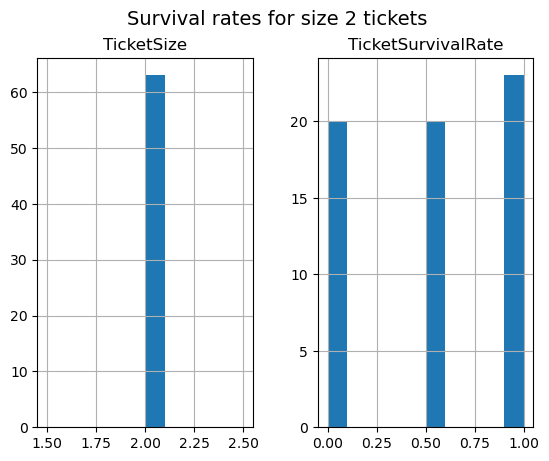

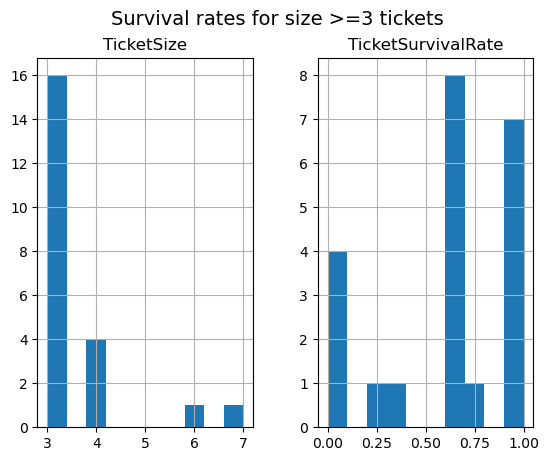

In [91]:
# Get all group ticket numbers and their sizes
total_data = pd.concat([labelled_data, unlabelled_data], axis = 0)
ticket_sizes = labelled_data["Ticket"].value_counts()
group_ticket_sizes = ticket_sizes[labelled_data["Ticket"].value_counts() > 1]

# Remove the group ticket numbers that oppear in the unlabelled dataset
for ticket_number in unlabelled_data["Ticket"]:
    if ticket_number in group_ticket_sizes.index:
        group_ticket_sizes = group_ticket_sizes.drop(ticket_number)

# Calculate the survival fraction for each group ticket
survival_data_each_group = {"Ticket": [], "TicketSize" : [], "TicketSurvivalRate" : []}
for ticket_number in group_ticket_sizes.index:
    ticket_holders = labelled_data[labelled_data["Ticket"] == ticket_number]
    survival_data_each_group["Ticket"].append(ticket_number)
    survival_data_each_group["TicketSize"].append(ticket_holders.shape[0])
    survival_data_each_group["TicketSurvivalRate"].append(ticket_holders["Survived"].mean())

survival_df = pd.DataFrame(survival_data_each_group)

# Visualise the statistics for small groups (size == 2) and larger groups (size >= 3)
axes = survival_df[survival_df["TicketSize"] == 2].hist()
axes.flatten()[0].get_figure().suptitle("Survival rates for size 2 tickets", fontsize=14)
axes = survival_df[survival_df["TicketSize"] >= 3].hist()
axes.flatten()[0].get_figure().suptitle("Survival rates for size >=3 tickets", fontsize=14)


We observe that, for tickets of sizes at least $3$, the whole group tend to either all fail to survive, or have most members survive - it is rare to observe a lone surviver.

On the other hand, for tickets of size $2$, the trend is less clear.

We make two hypotheses:
1. The male members holding group tickets tend to not survive, whilst female members tend to survive.
2. The survival rate of members is in positive correlation with the ticket survival rate. (I.e., a member is more likely to survive if other members tend to survive.)

Let us check these hypotheses by calculating the statistics. This time we need to calculate TicketSurvivalRate a little differently - it has to be the survival rate of the ticket _excluding_ the current passenger, otherwise there is a data leak (predicting own survival by knowing the overall survival rate of the ticket).

Text(0.5, 1.0, 'Passenger survival rates by TicketSurvivalRate')

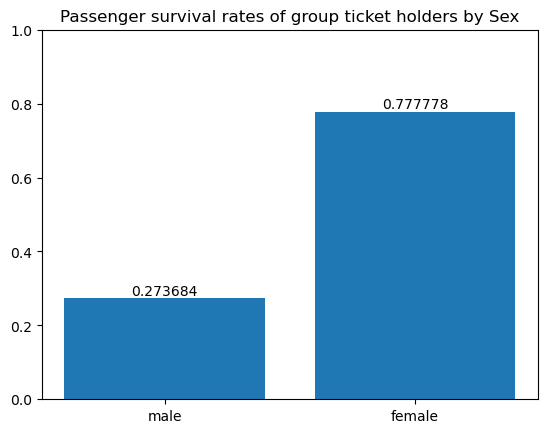

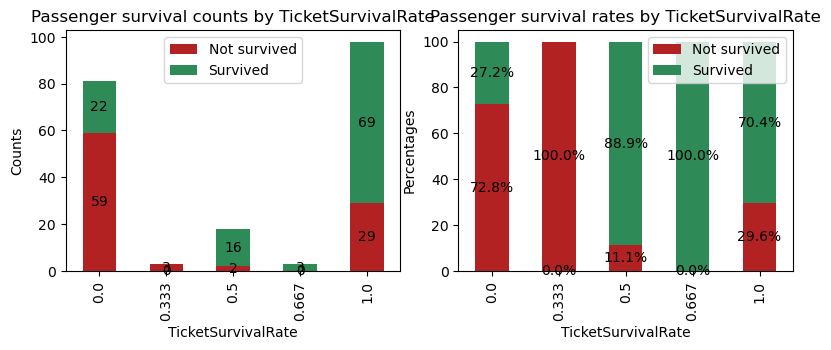

In [92]:
# Extract and calculate stats for tickets
survival_data = {"PassengerId" : [], "Ticket": [], "TicketSize" : [], "TicketSurvivalRate" : [], "Sex": [], "Age" : [], "Survived" : []}
for ticket_number in group_ticket_sizes.index:
    ticket_holders = labelled_data[labelled_data["Ticket"] == ticket_number]
    ticket_size = ticket_holders.shape[0]
    for ticket_holder in ticket_holders.iterrows():
        passengerId = ticket_holder[1]["PassengerId"]
        passengerEntry = labelled_data[labelled_data["PassengerId"] == passengerId]
        index_to_drop = ticket_holders[ticket_holders["PassengerId"] == passengerId].index
        ticket_survival_rate = ticket_holders.drop(index_to_drop)["Survived"].mean()
        survival_data["PassengerId"].append(passengerId)
        survival_data["Ticket"].append(ticket_number)
        survival_data["TicketSize"].append(ticket_size)
        survival_data["TicketSurvivalRate"].append(ticket_survival_rate)
        survival_data["Sex"].append(passengerEntry["Sex"].values[0])
        survival_data["Age"].append(passengerEntry["Age"].values[0])
        survival_data["Survived"].append(passengerEntry["Survived"].values[0])

survival_df = pd.DataFrame(survival_data)

# Visualise the gender-based survival rates
survival_rates = [survival_df[survival_df["Sex"] == "male"]["Survived"].mean(),survival_df[survival_df["Sex"] == "female"]["Survived"].mean()]
bars = plt.bar(["male","female"], survival_rates)
plt.ylim([0,1])
plt.title("Passenger survival rates of group ticket holders by Sex")
plt.bar_label(bars)

# Visualise the relationship between survivals and ticket survival rates
survival_df["TicketSurvivalRate"] = survival_df["TicketSurvivalRate"].round(3)

counts = survival_df["TicketSurvivalRate"].value_counts()

survived_counts = survival_df.groupby("TicketSurvivalRate", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
plt.tight_layout()

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Passenger survival counts by TicketSurvivalRate")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Passenger survival rates by TicketSurvivalRate")


Seems like holding a group ticket does not affect the survival rate of each genders by a statistically significant amount. On the other hand, there is a clear correlation between survival and survival rate $>= 0.5$, except a small rise of survival rate for TicketSurvivalRate $= 0.0$ and a small drop in survival rate for TicketSurvivalRate $= 1.0$.

We make the hypothesis that these two anomalies are mainly due to male passengers sacrificing themselves for female and children passengers in the same group ticket. Let us verify our hypothesis:

Text(0.5, 1.0, 'Passenger survival rates by TicketSurvivalRate, female passengers')

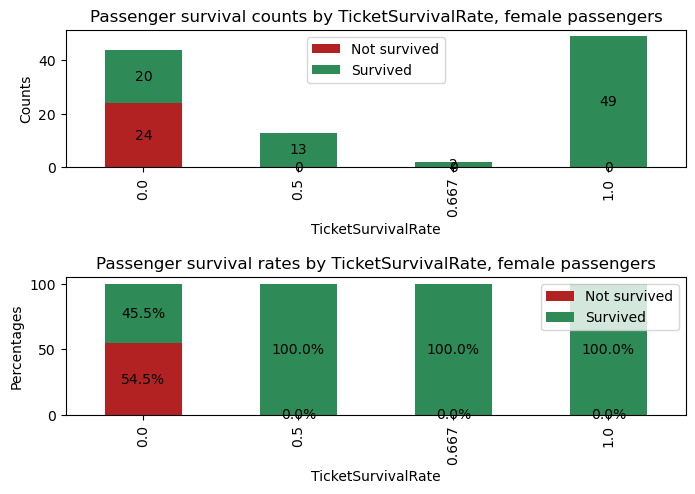

In [93]:
temp = survival_df[survival_df["Sex"] == "female"].copy(deep = True)

# Visualise the relationship between survivals and ticket survival rates
temp["TicketSurvivalRate"] = temp["TicketSurvivalRate"].round(3)

counts = temp["TicketSurvivalRate"].value_counts()

survived_counts = temp.groupby("TicketSurvivalRate", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=2, ncols=1, figsize=(8, 5))
plt.subplots_adjust(hspace=0.8)

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Passenger survival counts by TicketSurvivalRate, female passengers")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Passenger survival rates by TicketSurvivalRate, female passengers")


Text(0.5, 1.0, 'Passenger survival rates by TicketSurvivalRate, male passengers, age > 22')

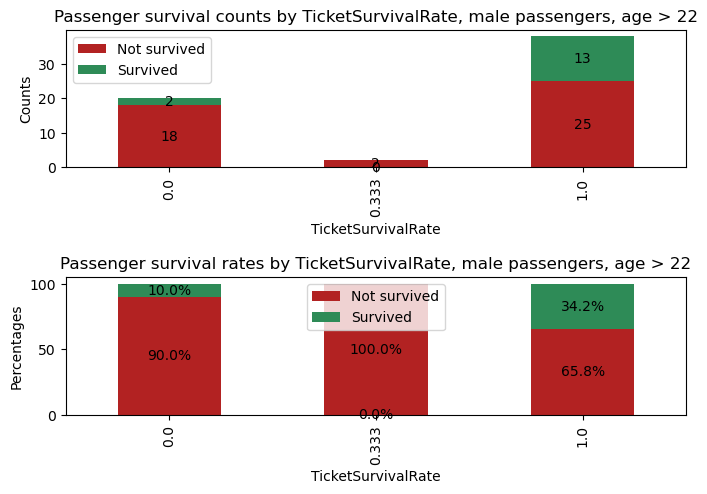

In [94]:
temp = survival_df[(survival_df["Sex"] == "male") & (survival_df["Age"] > 22)].copy(deep = True)

# Visualise the relationship between survivals and ticket survival rates
temp["TicketSurvivalRate"] = temp["TicketSurvivalRate"].round(3)

counts = temp["TicketSurvivalRate"].value_counts()

survived_counts = temp.groupby("TicketSurvivalRate", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=2, ncols=1, figsize=(8, 5))
plt.subplots_adjust(hspace=0.8)

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Passenger survival counts by TicketSurvivalRate, male passengers, age > 22")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Passenger survival rates by TicketSurvivalRate, male passengers, age > 22")


Text(0.5, 1.0, 'Passenger survival rates by TicketSurvivalRate, male passengers, age <= 22')

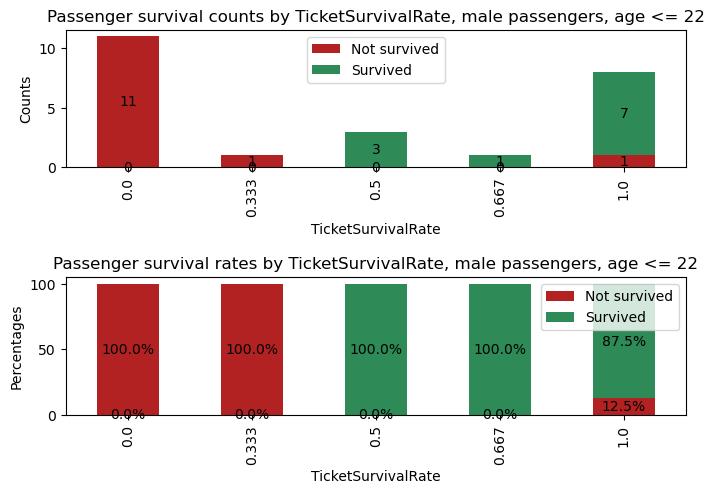

In [95]:
temp = survival_df[(survival_df["Sex"] == "male") & (survival_df["Age"] <= 22)].copy(deep = True)

# Visualise the relationship between survivals and ticket survival rates
temp["TicketSurvivalRate"] = temp["TicketSurvivalRate"].round(3)

counts = temp["TicketSurvivalRate"].value_counts()

survived_counts = temp.groupby("TicketSurvivalRate", observed = False)["Survived"].value_counts().sort_index()
survived_percentages = 100 * survived_counts / counts

fig, (ax_count, ax_percentage) = plt.subplots(nrows=2, ncols=1, figsize=(8, 5))
plt.subplots_adjust(hspace=0.8)

survived_counts.unstack().plot(kind="bar", stacked=True, ax=ax_count, color = ["firebrick","seagreen"])
ax_count.legend(["Not survived","Survived"])
ax_count.bar_label(ax_count.containers[0], label_type="center")
ax_count.bar_label(ax_count.containers[1], label_type="center")
ax_count.set_ylabel("Counts")
ax_count.set_title("Passenger survival counts by TicketSurvivalRate, male passengers, age <= 22")

survived_percentages.unstack().plot(kind="bar", stacked=True, ax=ax_percentage, color = ["firebrick","seagreen"])
ax_percentage.legend(["Not survived","Survived"])
ax_percentage.bar_label(ax_percentage.containers[0], fmt="%.1f%%", label_type="center")
ax_percentage.bar_label(ax_percentage.containers[1], fmt="%.1f%%", label_type="center")
ax_percentage.set_ylabel("Percentages")
ax_percentage.set_title("Passenger survival rates by TicketSurvivalRate, male passengers, age <= 22")


We conclude that:
- Female passengers holding a group ticket with a ticket survival rate of $0.5$ or higher is almost guaranteed to survive. But with a low ticket survival rate of $0.0$, the survival rate is dropped from the $0.8$ gender average to around $0.45$. (Survive when group survives, and sometimes survive when group doesn't survive.)
- Male passengers aged $22$ or below has a clear split - those with a ticket survival rate of $0.5$ or higher is almost guaranteed to survive, but with a lower ticket survival rate they almost never survive. (Survive exactly when group survives.)
- Male passengers aged above $22$ almost never survive in group tickets, with a small $0.35$ chance to survive if the whole group survives. (A chance to survive only when group survives.)

To include our findings in our predictions, we categorise the passengers by a few new features:
- FemaleInSurvivingGroup : $1$ if passenger is female and TicketSurvivalRate $>= 0.5$; else $0$.
- FemaleInDoomedGroup : $1$ if passenger is female and TicketSurvivalRate $< 0.5$; else $0$.
- BoyInSurvivingGroup : $1$ if passenger is male with Age $<= 22$ and TicketSurvivalRate $>= 0.5$; else $0$.
- BoyInDoomedGroup : $1$ if passenger is male with Age $<= 22$ and TicketSurvivalRate $< 0.5$; else $0$.
- ManInSurvivingGroup: $1$ if passenger is male with Age $> 22$ and TicketSurvivalRate $>= 0.5$; else $0$.
- ManInDoomedGroup: $1$ if passenger is male with Age $> 22$ and TicketSurvivalRate $< 0.5$; else $0$.

If a passenger has a ticket of size $1$, then all these columns will be $0$.

Calculating TicketSurvivalRate for tickets with members in the unlabelled dataset is a problem. We address this by:
- If a group ticket has some members in the labelled dataset, use their survival outcomes to calculate the TicketSurvivalRate.
- If a group ticket has no members in the labelled dataset, treat everyone as if they have a unique ticket (i.e. all new features set to $0$).

Computing data:

In [133]:
# Get all group ticket numbers and their sizes
total_data = pd.concat([labelled_data, unlabelled_data], axis = 0)
ticket_sizes = labelled_data["Ticket"].value_counts()
group_ticket_sizes = ticket_sizes[labelled_data["Ticket"].value_counts() > 1]

# Calculate ticket related data
survival_data = {"PassengerId" : [], "Ticket": [], "TicketSize" : [], "TicketSurvivalRate": []}
for ticket_number in group_ticket_sizes.index:
    #filtered_labelled_data = labelled_data[labelled_data["Ticket"] == ticket_number].copy(deep = False)
    #filtered_unlabelled_data = unlabelled_data[unlabelled_data["Ticket"] == ticket_number].copy(deep = False)
    ticket_holders = total_data[total_data["Ticket"] == ticket_number].copy(deep = False)
    ticket_size = ticket_holders.shape[0]
    for ticket_holder in ticket_holders.iterrows():
        passengerId = ticket_holder[1]["PassengerId"]
        index_to_drop = ticket_holders[ticket_holders["PassengerId"] == passengerId].index
        ticket_survival_rate = ticket_holders.drop(index_to_drop)["Survived"].mean() # NaN values from the unlabelled dataset are automatically discarded
        survival_data["PassengerId"].append(passengerId)
        survival_data["Ticket"].append(ticket_number)
        survival_data["TicketSize"].append(ticket_size)
        survival_data["TicketSurvivalRate"].append(ticket_survival_rate)
survival_df = pd.DataFrame(survival_data)

# Add feature TicketSurvivalRate to the datasets (a copy of them)
labelled_temp = labelled_data.copy(deep = True)
labelled_temp = pd.merge(labelled_temp, survival_df[["PassengerId", "TicketSurvivalRate"]], on = "PassengerId", how = "left")
unlabelled_temp = unlabelled_data.copy(deep = True)
unlabelled_temp = pd.merge(unlabelled_temp, survival_df[["PassengerId", "TicketSurvivalRate"]], on = "PassengerId", how = "left")

# Add engineered features to the datasets
# Rows with TicketSurvivalRate being NaN are the unique ticker holders, and the new features are automatically set to False by the following conditions
labelled_temp["FemaleInSurvivingGroup"] = (labelled_temp["Sex"] == "female") & (labelled_temp["TicketSurvivalRate"] >= 0.5)
labelled_temp["FemaleInDoomedGroup"] = (labelled_temp["Sex"] == "female") & (labelled_temp["TicketSurvivalRate"] < 0.5)
labelled_temp["BoyInSurvivingGroup"] = (labelled_temp["Sex"] == "male") & (labelled_temp["Age"] <= 22) & (labelled_temp["TicketSurvivalRate"] >= 0.5)
labelled_temp["BoyInDoomedGroup"] = (labelled_temp["Sex"] == "male") & (labelled_temp["Age"] <= 22) & (labelled_temp["TicketSurvivalRate"] < 0.5)
labelled_temp["ManInSurvivingGroup"] = (labelled_temp["Sex"] == "male") & (labelled_temp["Age"] > 22) & (labelled_temp["TicketSurvivalRate"] >= 0.5)
labelled_temp["ManInDoomedGroup"] = (labelled_temp["Sex"] == "male") & (labelled_temp["Age"] > 22) & (labelled_temp["TicketSurvivalRate"] < 0.5)

unlabelled_temp["FemaleInSurvivingGroup"] = (unlabelled_temp["Sex"] == "female") & (unlabelled_temp["TicketSurvivalRate"] >= 0.5)
unlabelled_temp["FemaleInDoomedGroup"] = (unlabelled_temp["Sex"] == "female") & (unlabelled_temp["TicketSurvivalRate"] < 0.5)
unlabelled_temp["BoyInSurvivingGroup"] = (unlabelled_temp["Sex"] == "male") & (unlabelled_temp["Age"] <= 22) & (unlabelled_temp["TicketSurvivalRate"] >= 0.5)
unlabelled_temp["BoyInDoomedGroup"] = (unlabelled_temp["Sex"] == "male") & (unlabelled_temp["Age"] <= 22) & (unlabelled_temp["TicketSurvivalRate"] < 0.5)
unlabelled_temp["ManInSurvivingGroup"] = (unlabelled_temp["Sex"] == "male") & (unlabelled_temp["Age"] > 22) & (unlabelled_temp["TicketSurvivalRate"] >= 0.5)
unlabelled_temp["ManInDoomedGroup"] = (unlabelled_temp["Sex"] == "male") & (unlabelled_temp["Age"] > 22) & (unlabelled_temp["TicketSurvivalRate"] < 0.5)

# Create clean data
clean_labelled_data_engineered = pd.concat([clean_labelled_data, labelled_temp[[
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]].astype(int)], axis = 1)
clean_unlabelled_data_engineered = pd.concat([clean_unlabelled_data, unlabelled_temp[[
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]].astype(int)], axis = 1)

Selecting features and searching for best parameters, using a __logistic regression__ model:

In [134]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV

# Loading the cleaned data with some missing Age values
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Defining the model
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer()),
    ("logreg", LogisticRegression()),
])

# Defining the GridSearchCV object
N_values = np.arange(1,30,2)
C_values = np.arange(0.1,3.05,0.1)
param_grid = {
    "KNN__n_neighbors" : N_values,
    "logreg__C" : C_values,
}
grid_search_cv_log_engineered = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_log_engineered.fit(temp_labelled_data_X,temp_labelled_data_y)

#results = pd.DataFrame(grid_search_cv_4.cv_results_)
#results["frac_errors"] = 1 - results["mean_test_score"]
#results.plot.line("param_logreg__C", "frac_errors", title = "C against fractional errors, averaged over 5-Fold Cross-Validation")
#results.plot.line("param_KNN__n_neighbors", "frac_errors", title = "N against fractional errors, averaged over 5-Fold Cross-Validation")


,estimator,Pipeline(step...egression())])
,param_grid,"{'KNN__n_neighbors': array([ 1, 3..., 25, 27, 29]), 'logreg__C': array([0.1, 0....8, 2.9, 3. ])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


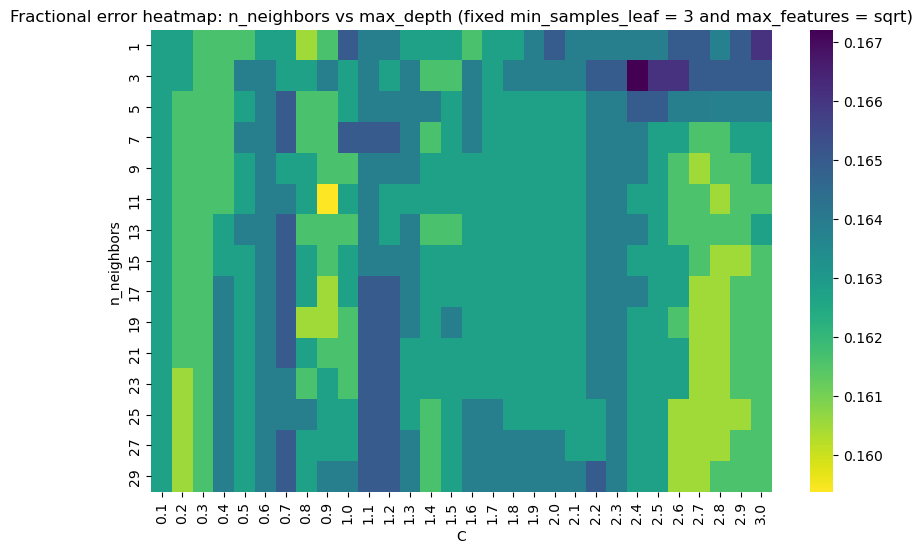

In [151]:
results = pd.DataFrame(grid_search_cv_log_engineered.cv_results_)
results["frac_errors"] = 1 - results["mean_test_score"]
results["param_logreg__C"] = results["param_logreg__C"].astype(float).round(2)

import seaborn as sns

# Extracting heatmap data
heatmap_data = results.pivot(
    index="param_KNN__n_neighbors", 
    columns="param_logreg__C", 
    values="frac_errors"
)

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=False, cmap="viridis_r", fmt=".4f")
plt.title("Fractional error heatmap: n_neighbors vs max_depth (fixed min_samples_leaf = 3 and max_features = sqrt)")
plt.xlabel("C")
plt.ylabel("n_neighbors")
plt.show()

In [153]:
results_sorted = results.sort_values("frac_errors")[["param_KNN__n_neighbors","param_logreg__C","frac_errors"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_logreg__C,frac_errors
158,11,0.9,0.159375
446,29,2.7,0.160486
357,23,2.8,0.160486
445,29,2.6,0.160486
238,15,2.9,0.160486
237,15,2.8,0.160486
266,17,2.7,0.160486
356,23,2.7,0.160486
297,19,2.8,0.160486
385,25,2.6,0.160486


aaaaaaa

In [158]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer


# Load training and testing data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data_engineered[[
    "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer(n_neighbors = 9)),
    ("logreg", LogisticRegression(C = 2.7)),
])

# Fit the model
model.fit(temp_labelled_data_X, temp_labelled_data_y)

# Make predictions!
y_pred = model.predict(temp_unlabelled_data_X)

# Save predictions to file
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/logreg_engineered_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


__Random Forest:__

In [240]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Load training data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer()),
    ("random_forest", RandomForestClassifier(random_state = 1))
])

# Create the param grid
N_values = [10,15,20]
max_depth_values = [10,12,14,16,18,20,22,24,26,28,30]
min_samples_leaf_values = [1,3,5,7]
max_features_values = ["sqrt"]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "random_forest__max_depth" : max_depth_values,
    "random_forest__min_samples_leaf" : min_samples_leaf_values,
    "random_forest__max_features" : max_features_values,
}

# Create and fit GridSearchCV
grid_search_cv_rf_engineered = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_rf_engineered.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [241]:
results = pd.DataFrame(grid_search_cv_rf_engineered.cv_results_)
results.to_csv("./results/RandomForestClassifierGridSearchCV_Engineered_sqrt_only.csv")

In [242]:
results_file_path = "./results/RandomForestClassifierGridSearchCV_Engineered_sqrt_only.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_random_forest__max_depth","param_random_forest__max_features","param_random_forest__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_random_forest__max_depth,param_random_forest__max_features,param_random_forest__min_samples_leaf,frac_error
61,15,18,sqrt,3,0.149237
77,15,26,sqrt,3,0.149237
73,15,24,sqrt,3,0.149237
85,15,30,sqrt,3,0.149237
81,15,28,sqrt,3,0.149237
69,15,22,sqrt,3,0.149237
121,20,26,sqrt,3,0.149269
125,20,28,sqrt,3,0.149269
129,20,30,sqrt,3,0.149269
65,15,20,sqrt,3,0.150361


In [243]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer


# Load training and testing data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data_engineered[[
    "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer(n_neighbors = 15)),
    ("random_forest", RandomForestClassifier(max_depth = 18, min_samples_leaf = 3, max_features = "sqrt", random_state = 1))
])

# Fit the model
model.fit(temp_labelled_data_X, temp_labelled_data_y)

# Make predictions!
y_pred = model.predict(temp_unlabelled_data_X)

# Save predictions to file
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/rf_engineered_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


__Gradient boosted forest:__

In [249]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Load training data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [5,10,20]
n_estimators = [50,100,200]
learning_rates = [0.01,0.05,0.1,0.2,0.3]
max_depths = [2,3,4,5]
min_samples_leaf_values = [5,10,20]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc_engineered = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc_engineered.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [256]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCV_Engineered.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:20]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
339,10,50,0.30,3,20,0.142527
273,10,50,0.10,4,10,0.147009
62,5,200,0.05,4,20,0.147015
483,20,50,0.20,3,20,0.147015
89,5,200,0.10,3,20,0.147022
519,20,50,0.30,3,20,0.147028
401,20,200,0.05,2,10,0.148133
321,10,50,0.20,5,20,0.148145
309,10,50,0.20,4,10,0.148151
150,5,50,0.30,2,20,0.148151


A more refined hyperparameter search:

In [259]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Load training data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [10,15]
n_estimators = [100,150,200,250,300]
learning_rates = [0.03,0.05,0.075,0.1,0.15]
max_depths = [3,4]
min_samples_leaf_values = [10,15,20,25,30,35]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc_engineered = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc_engineered.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [263]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCV_Engineered_Fine.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:30]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
359,15,300,0.030,4,35,0.138045
113,10,250,0.050,4,30,0.140286
476,15,150,0.075,4,35,0.140286
353,15,250,0.030,4,30,0.141391
53,10,250,0.030,4,30,0.141397
535,15,100,0.100,4,35,0.141410
417,15,200,0.050,4,35,0.141410
555,15,100,0.150,3,25,0.141416
438,15,250,0.075,3,25,0.141422
331,15,150,0.030,4,10,0.142521


Low learning_rate with high n_estimators seemed to perform the best. Since parameters learning_rate, n_estimators and min_samples_leaf seem to be constraining the model's performance, we carry out one last refined search:

In [267]:
raise Exception("This cell is intentionally disabled due to long compute time.")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Load training data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer()),
    ("gbc", GradientBoostingClassifier(random_state = 1))
])

# Create the param grid
N_values = [15]
n_estimators = [200,300,400,500,600]
learning_rates = [0.01,0.02,0.03,0.04]
max_depths = [4]
min_samples_leaf_values = [30,35,40,45,50]
param_grid = {
    "KNN__n_neighbors" : N_values,
    "gbc__n_estimators" : n_estimators,
    "gbc__learning_rate" : learning_rates,
    "gbc__max_depth" : max_depths,
    "gbc__min_samples_leaf" : min_samples_leaf_values
}

# Create and fit GridSearchCV
grid_search_cv_gbc_engineered = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy")
grid_search_cv_gbc_engineered.fit(temp_labelled_data_X, temp_labelled_data_y)


Exception: This cell is intentionally disabled due to long compute time.

In [266]:
results_file_path = "./results/GradientBoostingClassifierGridSearchCV_Engineered_Fine_2.csv"
results = pd.read_csv(results_file_path)
results["frac_error"] = 1 - results["mean_test_score"]

results_sorted = results.sort_values("frac_error")[["param_KNN__n_neighbors","param_gbc__n_estimators","param_gbc__learning_rate","param_gbc__max_depth","param_gbc__min_samples_leaf","frac_error"]].copy(deep = False)
results_sorted[:30]

,param_KNN__n_neighbors,param_gbc__n_estimators,param_gbc__learning_rate,param_gbc__max_depth,param_gbc__min_samples_leaf,frac_error
56,15,300,0.03,4,35,0.138045
80,15,200,0.04,4,35,0.138045
33,15,500,0.02,4,35,0.139163
81,15,300,0.04,4,35,0.139175
57,15,400,0.03,4,35,0.140293
32,15,400,0.02,4,35,0.141416
34,15,600,0.02,4,35,0.141416
27,15,400,0.02,4,30,0.142527
51,15,300,0.03,4,30,0.142527
96,15,300,0.04,4,50,0.142527


The set of parameters n_neighbors = $15$, n_estimators = $300$, learning_rate = $0.03$, max_depth = $4$, min_samples_leaf = $35$ stayed as the top performer, so we use this set of parameters to train our model:

In [270]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Load training and testing data
temp_labelled_data = clean_labelled_data_engineered[[
    "Survived", "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]
temp_labelled_data_X = temp_labelled_data.drop("Survived", axis = 1)
temp_labelled_data_y = temp_labelled_data["Survived"]
temp_unlabelled_data_X = clean_unlabelled_data_engineered[[
    "Pclass", "Master", "Mr", "Mrs", "Miss", "IsFemale", "LogFamilySize", "LogAvgFare", "Age",
    "FemaleInSurvivingGroup","FemaleInDoomedGroup","BoyInSurvivingGroup","BoyInDoomedGroup","ManInSurvivingGroup","ManInDoomedGroup"
]]

# Create the pipeline
model = Pipeline([
    ("scaler", MinMaxScaler().set_output(transform = "pandas")),
    ("KNN", KNNImputer(n_neighbors = 15)),
    ("gbc", GradientBoostingClassifier(n_estimators = 300, learning_rate = 0.03, max_depth = 4, min_samples_leaf = 35, random_state = 1))
])

# Fit the model
model.fit(temp_labelled_data_X, temp_labelled_data_y)

# Make predictions!
y_pred = model.predict(temp_unlabelled_data_X)

# Save predictions to file
passengerIds = np.arange(892,1310,1)
y_pred_df = pd.DataFrame({"PassengerId" : passengerIds, "Survived" : y_pred})

y_pred_df.to_csv('./predictions/gbc_engineered_pred.csv', index=False)

print("Prediction header:")
print(y_pred_df.head())

Prediction header:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
